CONTENTS:
- [Exploratory Data Analysis: FRED Metadata](#exploratory-data-analysis:-fred-metadata)
  - [Introduction](#introduction)
  - [Imports](#imports)
  - [Load Data](#load-data)
    - [Column information](#column-information)
  - [Preprocessing](#preprocessing)
  - [Common Plotting Functions](#common-plotting-functions)
  - [Filtering Functions](#filtering-functions)
  - [Introductory Analytics](#introductory-analytics)
    - [Missing Data](#missing-data)
    - [Descriptor Analytics](#descriptor-analytics)
    - [Top Data Sources](#top-data-sources)
  - [Data Freshness](#data-freshness)
    - [Start/End Cohorts by Decade](#start/end-cohorts-by-decade)
    - [Discontinued Series](#discontinued-series)
    - [Active/Discontinued by Source](#active/discontinued-by-source)
    - [Top 20 Discontinued by Data Source](#top-20-discontinued-by-data-source)
    - [Top 20 Discontinued by Tag](#top-20-discontinued-by-tag)
    - [Top 20 Discontinued by Category](#top-20-discontinued-by-category)
    - [Frequency of Data](#frequency-of-data)
    - [Base Frequency by Data Source](#base-frequency-by-data-source)
  - [Seasonal Adjustment Analysis](#seasonal-adjustment-analysis)
  - [Analyses on Categories and Tags](#analyses-on-categories-and-tags)
    - [Categories Distribution](#categories-distribution)
    - [Hierarchical Categorical Analyses](#hierarchical-categorical-analyses)
    - [Tags Distribution](#tags-distribution)
    - [Distribution of Tag Categories](#distribution-of-tag-categories)
    - [Count of Tags and Categories per Series](#count-of-tags-and-categories-per-series)
    - [Top Tags for Each Root Category](#top-tags-for-each-root-category)
  - [Geographical Analysis](#geographical-analysis)
    - [US vs Non-US](#us-vs-non-us)
    - [Breakdown by Continent](#breakdown-by-continent)
    - [Distribution of Data by State](#distribution-of-data-by-state)
  - [Analyses of some Derived Features](#analyses-of-some-derived-features)
    - [Derived Feature Correlation](#derived-feature-correlation)
    - [Duration vs Staleness](#duration-vs-staleness)

<a name='exploratory-data-analysis:-fred-metadata'></a>
# Exploratory Data Analysis: FRED Metadata

<a name='introduction'></a>
## Introduction

This notebook draws statistical insights from the metadata of the Federdal Reserve Economic Database. The goal is to get a full picture of what data is available on FRED, including tag/category distributions, temporal and geographic breakdowns, source comparisons, and more.

<a name='imports'></a>
<a name='import-necessary-packages-and-load-the-metadata'></a>
## Imports

In [21]:
%load_ext autoreload
%autoreload 2
import json
import re
import textwrap
from collections import Counter, defaultdict
from typing import Dict, List, Optional, Sequence, Tuple

import helpers.hopenai as hopenai
import helpers.hs3 as hs3
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.collections import PatchCollection
from matplotlib.patches import Polygon
from matplotlib.ticker import FuncFormatter

# Notebook styling
sns.set_theme(style="whitegrid")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [22]:
# Set configurations.
fred_path = "s3://causify-data-collaborators/causal_automl/metadata/fred_series_metadata.csv"
country_continent_path = "s3://causify-data-collaborators/causal_automl/supplemental_data/country_continent.csv"
us_states_path = "s3://causify-data-collaborators/causal_automl/supplemental_data/us_states.geojson"
# Set top N for bar charts.
N = 20

<a name='load-data'></a>
## Load Data

In [ ]:
s3 = hs3.get_s3fs("ck")
stream = s3.open(fred_path, mode="r")
fred = pd.read_csv(stream, engine="python", on_bad_lines="skip")
# Load country to continent mapper.
with s3.open(country_continent_path) as f:
    cc = pd.read_csv(f)
# Load US state data.
with s3.open(us_states_path, mode="r") as f:
    geo = json.load(f)

In [24]:
print(fred.shape)
print(fred.columns)
fred.head(5)

(642162, 13)
Index(['id', 'title', 'description', 'tags', 'last_updated', 'units',
       'frequency', 'seasonal_adjustment', 'notes', 'categories',
       'data_source', 'start_date', 'end_date'],
      dtype='object')


,id,title,description,tags,last_updated,units,frequency,seasonal_adjustment,notes,categories,data_source,start_date,end_date
0,NROU,Noncyclical Rate of Unemployment,Graph and download economic data for Noncyclic...,nairu; cbo; long-term; projection; unemploymen...,2025-03-17T15:44:00-05:00,Percent,Quarterly,Not Seasonally Adjusted,"Starting with the July, 2021 report:An Update ...","Population, Employment, & Labor Markets",U.S. Congressional Budget Office,1949-01-01,2035-10-01
1,NROUST,Natural Rate of Unemployment (Short-Term) (DIS...,Graph and download economic data for Natural R...,nairu; cbo; short-term; projection; discontinu...,2021-02-01T14:37:00-06:00,Percent,Quarterly,Not Seasonally Adjusted,"This series last appeared in the February, 202...","Population, Employment, & Labor Markets",U.S. Congressional Budget Office,1949-01-01,2031-10-01
2,LNU04032183,Unemployment Rate - Asian,Graph and download economic data for Unemploym...,asian; 16 years +; household survey; unemploym...,2025-03-07T07:46:00-06:00,Percent,Monthly,Not Seasonally Adjusted,The series comes from the 'Current Population ...,"Population, Employment, & Labor Markets; Curre...",U.S. Bureau of Labor Statistics,2000-01-01,2025-03-01
3,U4RATE,"Total Unemployed Plus Discouraged Workers, as ...",Graph and download economic data for Total Une...,discouraged; labor underutilization; workers; ...,2025-03-07T07:46:00-06:00,Percent,Monthly,Seasonally Adjusted,The series comes from the 'Current Population ...,"Population, Employment, & Labor Markets; Curre...",U.S. Bureau of Labor Statistics,1994-01-01,2025-03-01
4,LNS14000025,"Unemployment Rate - 20 Yrs. & over, Men",Graph and download economic data for Unemploym...,20 years +; males; household survey; unemploym...,2025-03-07T07:48:00-06:00,Percent,Monthly,Seasonally Adjusted,The series comes from the 'Current Population ...,"Population, Employment, & Labor Markets; Curre...",U.S. Bureau of Labor Statistics,1948-01-01,2025-03-01


<a name='column-information'></a>
### Column information

| Column                | Description                                                      |
|-----------------------|------------------------------------------------------------------|
| `id`                | Unique FRED series identifier (e.g. “NROU”).                     |
| `title`             | Human‐readable name of the series.                               |
| `description`       | Full text describing what the series measures.                   |
| `tags`              | Semicolon‑separated keywords associated with the series.         |
| `last_updated`      | Timestamp of the most recent metadata update for this series.    |
| `units`             | Units of measurement (e.g. “Percent”, “USD”).                    |
| `frequency`         | Reporting frequency (e.g. “Monthly”, “Quarterly”, etc.).         |
| `seasonal_adjustment` | Indicates whether data are seasonally adjusted (e.g. “SA” or “Not Seasonally Adjusted”). |
| `notes`             | Additional commentary or caveats about the series.               |
| `categories`        | Semicolon‑separated high‑level classification(s) of the series.  |
| `data_source`       | Originating agency or organization that publishes the data.      |
| `start_date`        | Date of the first observation available for the series.          |
| `end_date`          | Date of the last (or most recent forecasted) observation.        |


<a name='preprocessing'></a>
## Preprocessing

In [ ]:
def _infer_country(row: pd.Series, country2cont: Dict[str, str]) -> Optional[str]:
    """
    Determine the country corresponding to the given row.

    Check the tags first for a matching country. If none is found,
    search the title, description, and notes fields.

    :param row: row with data including tags and text fields
    :param country2cont: mapping from country names to continents
    :return: first matching country if found, or np.nan if no match
        exists
    """
    for t in row["tags_list"] or []:
        tt = str(t).strip()
        if tt in country2cont:
            return tt
    for fld in ("title", "description", "notes"):
        for w in str(row.get(fld, "")).split():
            w0 = w.strip(",.()")
            if w0 in country2cont:
                return w0
    return np.nan


def preprocess_fred(df: pd.DataFrame, cc: pd.DataFrame) -> pd.DataFrame:
    """
    Preprocessing function.

    :param df: FRED metadata
    :param cc: country -> continent dataset
    :return: preprocessed data
    """
    df = df.copy()
    # Parse dates & drop tzinfo.
    df["last_updated"] = pd.to_datetime(
        df["last_updated"], utc=True, errors="coerce"
    ).dt.tz_convert(None)
    df["start_date"] = pd.to_datetime(
        df["start_date"], format="%Y-%m-%d", errors="coerce"
    )
    df["end_date"] = pd.to_datetime(
        df["end_date"], format="%Y-%m-%d", errors="coerce"
    )
    # Extract base frequency.
    df["freq_base"] = (
        df["frequency"].fillna("Not Available").str.split(",", n=1).str[0]
    )
    # Split tags & categories into lists, count them.
    df["tags_list"] = df["tags"].str.split(";")
    df["categories_list"] = (
        df["categories"]
        .fillna("")
        .str.split(";")
        .map(lambda L: [c.strip().title() for c in L if c.strip()])
    )
    df["n_tags"] = df["tags_list"].str.len().fillna(0).astype(int)
    df["n_categories"] = df["categories_list"].str.len().fillna(0).astype(int)
    # Flag discontinued series.
    df["is_discontinued"] = df["tags_list"].map(
        lambda lst: any(
            str(t).strip().lower() == "discontinued" for t in (lst or [])
        )
    )
    # Compute staleness, years, decades, duration.
    today = pd.Timestamp.today().normalize()
    df["staleness_days"] = (today - df["last_updated"]).dt.days
    df["last_year"] = df["last_updated"].dt.year
    df["start_year"] = df["start_date"].dt.year
    df["end_year"] = df["end_date"].dt.year
    df["start_decade"] = (df["start_year"] // 10) * 10
    df["end_decade"] = (df["end_year"] // 10) * 10
    # Duration in years (only where both dates valid).
    mask = df["start_date"].notna() & df["end_date"].notna()
    dur_days = (
        df.loc[mask, "end_date"].values.astype("datetime64[D]")
        - df.loc[mask, "start_date"].values.astype("datetime64[D]")
    ).astype(int)
    df["duration_years"] = np.nan
    df.loc[mask, "duration_years"] = dur_days / 365.0
    # Infer country & continent.
    cc["Country_Name"] = cc["Country_Name"].str.strip()
    cc["Continent_Name"] = cc["Continent_Name"].str.strip()
    country2cont = dict(zip(cc["Country_Name"], cc["Continent_Name"]))
    df["country"] = df.apply(
        lambda row: _infer_country(row, country2cont), axis=1
    )
    df["continent"] = df["country"].map(country2cont).fillna("Other")
    # Lengths of free‐text fields.
    df["title_len"] = df["title"].str.len().fillna(0).astype(int)
    df["desc_len"] = df["description"].str.len().fillna(0).astype(int)
    df["notes_len"] = df["notes"].str.len().fillna(0).astype(int)
    return df

In [26]:
fred = preprocess_fred(fred, cc)

<a name='common-plotting-functions'></a>
## Common Plotting Functions

In [27]:
def plot_top_n_annotated_bar(
    counts: pd.Series,
    total: int,
    top_n: int,
    *,
    wrap_width: Optional[int] = 30,
    cmap=plt.cm.Spectral,
    figsize=(12, 8),
    dpi=100,
    xlabel: str = "",
    ylabel: str = "Count",
    title: str = "",
    note_prefix: str = "Top {n} cover ",
    note_pos: tuple = (0.95, 0.85),
    rotation: int = 45,
    fontsize_title: int = 16,
    fontsize_labels: int = 10,
    fontsize_annotation: int = 10,
    fontsize_note: int = 11,
    formatter=None,
    annotation_fmt: str = "{pct:.1f}%",
    show_coverage_note: bool = True,
) -> Tuple[matplotlib.figure.Figure, matplotlib.axes.Axes]:
    """
    Plot the top N entries of counts as a bar chart and annotate each bar with
    its percentage of total.

    You can optionally add a coverage note.

    :param counts: count values keyed by label
    :param total: total to compute percentages against
    :param top_n: number of top entries to plot
    :param wrap_width: value to wrap long labels; if None, no wrapping
    :param cmap: colormap for bars
    :param figsize: dimensions of the figure
    :param dpi: resolution of the figure
    :param xlabel: label for the x-axis
    :param ylabel: label for the y-axis
    :param title: title of the chart
    :param note_prefix: template for coverage note, must include {n}
    :param note_pos: coordinates for coverage note in axes space
    :param rotation: rotation angle for tick labels
    :param fontsize_title: font size for the chart title
    :param fontsize_labels: font size for axis labels
    :param fontsize_annotation: font size for bar annotations
    :param fontsize_note: font size for the coverage note
    :param formatter: custom formatter for y-axis ticks
    :param annotation_fmt: template for bar-label annotations, must
        include {pct}
    :param show_coverage_note: indicates whether to display the coverage
        note
    :return: figure and axes references
    """
    # Select the top entries.
    top = counts.head(top_n)
    # Check if label wrapping is required.
    if wrap_width:
        labels = [textwrap.fill(lbl, wrap_width) for lbl in top.index]
    else:
        labels = list(top.index)
    # Extract the values.
    values = top.values
    # Compute overall coverage percentage.
    coverage = values.sum() / total * 100.0
    # Compute x positions for the bars.
    x = np.arange(len(top))
    # Generate colors for the bars.
    colors = cmap(np.linspace(0, 1, len(top)))
    # Create the figure and axes.
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    # Draw the bar chart.
    bars = ax.bar(x, values, color=colors, edgecolor="gray", linewidth=1)
    # Calculate a vertical offset for annotations.
    offset = max(values) * 0.01
    # Annotate each bar with its percentage.
    for b, cnt in zip(bars, values):
        pct = cnt / total * 100.0
        txt = annotation_fmt.format(pct=pct)
        ax.text(
            b.get_x() + b.get_width() * 0.5,
            cnt + offset,
            txt,
            ha="center",
            va="bottom",
            fontsize=fontsize_annotation,
        )
    # Configure x-axis ticks and labels.
    ax.set_xticks(x)
    ax.set_xticklabels(
        labels, rotation=rotation, ha="right", fontsize=fontsize_labels
    )
    # Set the labels and title of the chart.
    ax.set_xlabel(xlabel, fontsize=fontsize_labels)
    ax.set_ylabel(ylabel, fontsize=fontsize_labels)
    ax.set_title(title, fontsize=fontsize_title, pad=12)
    # Format y-axis ticks.
    if formatter:
        ax.yaxis.set_major_formatter(formatter)
    else:
        ax.yaxis.set_major_formatter(FuncFormatter(lambda v, p: f"{int(v):,}"))
    # Add a coverage note if required.
    if show_coverage_note:
        note = note_prefix.format(n=top_n) + f"{coverage:.1f}%"
        ax.text(
            note_pos[0],
            note_pos[1],
            note,
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=fontsize_note,
            bbox={
                "boxstyle": "round,pad=0.3",
                "fc": "white",
                "ec": "gray",
                "alpha": 0.7,
            },
        )
    # Adjust the layout.
    plt.tight_layout()
    return fig, ax

In [28]:
def plot_histograms(
    data_series,
    labels,
    colors,
    *,
    bins=50,
    kde=True,
    figsize=(8, 5),
    xlabel="",
    title="",
    legend_title=None,
    show_legend=True,
    xticks=None,
    xtick_labels=None,
    xticks_shift: float = 0.0,
    xticks_rotation: float = 0,
    invert_xaxis: bool = False,
) -> Tuple[matplotlib.figure.Figure, matplotlib.axes.Axes]:
    """
    Plot overlaid histograms with KDE and advanced x-axis control.

    :param data_series: data to plot
    :param labels: legend labels corresponding to each data series
    :param colors: colors for each data series
    :param bins: number of bins or bin edges
    :param kde: flag indicating whether to plot kernel density estimate
    :param figsize: size of the figure
    :param xlabel: label for the x-axis
    :param title: title of the chart
    :param legend_title: title for the legend
    :param show_legend: flag indicating whether to display the legend
    :param xticks: positions for x-ticks
    :param xtick_labels: labels for x-ticks
    :param xticks_shift: offset to add to each x-tick position
    :param xticks_rotation: angle for rotating x-tick labels
    :param invert_xaxis: flag indicating whether to invert the x-axis
    :return: figure and axis objects
    """
    # Create chart objects.
    fig, ax = plt.subplots(figsize=figsize)
    # Plot each dataset.
    for series, lbl, col in zip(data_series, labels, colors):
        sns.histplot(series, bins=bins, kde=kde, color=col, label=lbl, ax=ax)
    # Include legend.
    if show_legend and labels and any(labels):
        ax.legend(title=legend_title)
    # Label x-axis.
    ax.set_xlabel(xlabel)
    # Title chart.
    ax.set_title(title)
    # Shift x-ticks.
    if xticks is not None:
        shifted = np.array(xticks) + xticks_shift
        ax.set_xticks(shifted)
    # Set tick labels.
    if xtick_labels is not None:
        ax.set_xticklabels(xtick_labels, rotation=xticks_rotation)
    # Reverse x-axis.
    if invert_xaxis:
        ax.invert_xaxis()
    # Optimize layout.
    plt.tight_layout()
    # Finalize plot.
    return fig, ax

In [29]:
def plot_stacked_bar(
    df: pd.DataFrame,
    index_labels: list[str],
    xlabel: str,
    ylabel: str,
    title: str,
    legend_labels: list[str],
    colormap,
    *,
    width: float = 0.8,
    figsize: tuple = (14, 6),
    dpi: int = 100,
    bbox_to_anchor: tuple = (0, 0, 0.85, 1),
) -> Tuple[matplotlib.figure.Figure, matplotlib.axes.Axes]:
    """
    Plot a stacked bar chart.

    :param df: input chart data to plot as stacked bars
    :param index_labels: labels for the x-axis corresponding to each row
    :param xlabel: label for the x-axis
    :param ylabel: label for the y-axis
    :param title: title of the chart
    :param legend_labels: entries for the legend in the order of the
        data columns
    :param colormap: either a colormap or a sequence of colors for the
        bars
    :param width: width of the bars
    :param figsize: size of the figure
    :param dpi: dots per inch of the figure
    :param bbox_to_anchor: dimensions for figure layout adjustment to
        accommodate the legend
    :return: figure and axes
    """
    # Create figure and axes.
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    # Define plotting parameters.
    plot_kwargs = {
        "kind": "bar",
        "stacked": True,
        "ax": ax,
        "width": width,
        "edgecolor": "white",
        "linewidth": 1,
        "legend": False,
    }
    if isinstance(colormap, (list, tuple)):
        plot_kwargs["color"] = colormap
    else:
        plot_kwargs["colormap"] = colormap
    # Render the stacked bar chart.
    df.plot(**plot_kwargs)
    ax.set_xticks(np.arange(len(index_labels)))
    ax.set_xticklabels(index_labels, rotation=45, ha="right", fontsize=10)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=14, pad=12)
    ax.yaxis.set_major_formatter(lambda x, pos: f"{int(x):,}")
    ax.legend(legend_labels, title="", loc="upper right", fontsize=10)
    fig.tight_layout(rect=bbox_to_anchor)
    return fig, ax

In [30]:
def plot_donut(
    sizes,
    labels,
    title,
    *,
    colors=None,
    explode=None,
    figsize=(6, 6),
    fontsize=12,
) -> Tuple[matplotlib.figure.Figure, matplotlib.axes.Axes]:
    """
    Draw a donut-style pie chart.

    :param sizes: values for each slice
    :param labels: labels for each slice
    :param title: chart title
    :param colors: optional colors for slices
    :param explode: optional fractional offset for slices
    :param figsize: optional figure size
    :param fontsize: optional font size for slice annotations
    :return: figure and axes objects
    """
    # Create figure and axes.
    fig, ax = plt.subplots(figsize=figsize)
    # Set default colors if missing.
    if colors is None:
        colors = plt.cm.Set2(np.arange(len(sizes)))
    # Set default explosion if missing.
    if explode is None:
        explode = (0.05,) + (0,) * (len(sizes) - 1)
    # Draw pie chart with donut styling.
    ax.pie(
        sizes,
        labels=labels,
        autopct="%1.1f%%",
        startangle=90,
        pctdistance=0.75,
        colors=colors,
        explode=explode,
        wedgeprops={"linewidth": 1, "edgecolor": "white"},
        textprops={"fontsize": fontsize},
    )
    # Draw center circle.
    centre_circle = plt.Circle((0, 0), 0.45, fc="white", linewidth=0)
    ax.add_artist(centre_circle)
    # Set title and equal aspect.
    ax.set_title(title, fontsize=16, pad=20)
    ax.axis("equal")
    # Adjust layout and return objects.
    plt.tight_layout()
    return fig, ax

In [31]:
def plot_cumulative_coverage(
    cum_coverage: pd.Series,
    N: int,
    xlabel: str,
    ylabel: str,
    title: str,
    *,
    highlight_color: str = "red",
    linestyle: str = "--",
    figsize: tuple = (10, 6),
    dpi: int = 100,
    grid_alpha: float = 0.7,
) -> Tuple[matplotlib.figure.Figure, matplotlib.axes.Axes]:
    """
    Plot cumulative coverage curve and highlight the top-n cutoff.

    :param cum_coverage: cumulative coverage values sorted descending
    :param N: index at which to draw and label the horizontal cutoff
        line
    :param xlabel: label for the x axis
    :param ylabel: label for the y axis
    :param title: title of the plot
    :param highlight_color: color of the cutoff line
    :param linestyle: linestyle of the cutoff line]
    :param figsize: size of the figure
    :param dpi: figure dpi
    :param grid_alpha: alpha transparency for the horizontal grid
    :return: figure and axes objects
    """
    # Define x-axis positions.
    x = np.arange(1, len(cum_coverage) + 1)
    # Determine cutoff value.
    cutoff = cum_coverage.iloc[N - 1]
    # Create figure and axes.
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    ax.plot(x, cum_coverage.values, linewidth=2)
    ax.axhline(
        cutoff,
        color=highlight_color,
        linestyle=linestyle,
        label=f"Top {N} Coverage: {cutoff:.1f}%",
    )
    # Set labels and title.
    ax.set_xlabel(xlabel, fontsize=13)
    ax.set_ylabel(ylabel, fontsize=13)
    ax.set_title(title, fontsize=16, pad=12)
    ax.legend(loc="lower right")
    ax.grid(axis="y", linestyle="--", alpha=grid_alpha)
    # Adjust layout and return figure.
    plt.tight_layout()
    return fig, ax

<a name='filtering-functions'></a>
## Filtering Functions

In [32]:
def prepare_top_counts(
    df: pd.DataFrame,
    column: str,
    *,
    top_n: Optional[int] = None,
    filter_mask: Optional[pd.Series] = None,
    explode: bool = False,
    split: Optional[Tuple[str, int]] = None,
    drop: Sequence[str] = (),
    rename: dict = {},
    threshold: Optional[int] = None,
    include_other: bool = False,
    other_label: str = "Other",
) -> Tuple[pd.Series, int]:
    """
    Return a (counts, total) pair ready for plotting.

    :param df: data to count over
    :param column: column name to count over
    :param top_n: take only the top N after all other operations
    :param filter_mask: mask to pre‐filter df
    :param explode: if True, column must be list‐like and will be exploded first
    :param split: (separator, level) to split strings, e.g. (";", 0) for root or (";", -1) for leaf
    :param drop: indices to drop
    :param rename:i ndex renames
    :param threshold: if set, group any value with count < threshold into a single cell
    :param include_other: if True and top_n is set, append “Other” containing everything below top_n
    :param other_label: the label for that combined bucket

    :return:
             - counts: categories, with integer counts
             - total: total count over which percentages should be computed
    """
    # Get series, filter if needed.
    s = df[column]
    if filter_mask is not None:
        s = s[filter_mask]
    # Explode and split if applicable.
    if explode:
        s = s.explode()
    if split is not None:
        sep, lvl = split
        s = (
            s.fillna("")
            .astype(str)
            .str.split(sep)
            .apply(
                lambda L: (
                    L[lvl].strip()
                    if len(L) > abs(lvl) and L[lvl].strip()
                    else None
                )
            )
        )
    # Clean up, count values.
    s = s.dropna()
    counts = s.value_counts()
    # Adjust counts by dropping and renaming.
    if drop:
        counts.index = counts.index.str.strip()
        counts = counts.drop(index=drop, errors="ignore")
    if rename:
        counts = counts.rename(index=rename)
    # Set total count and group minor values.
    total = len(s)
    if threshold is not None:
        major = counts[counts >= threshold]
        minor = counts[counts < threshold].sum()
        counts = pd.concat([major, pd.Series({other_label: minor})])
    # Limit to top_n; add "Other" if required.
    if top_n is not None:
        top = counts.head(top_n)
        if include_other and len(counts) > top_n:
            other = counts.iloc[top_n:].sum()
            top = top.append(pd.Series({other_label: other}))
        counts = top
    return counts, total

In [33]:
def get_binary_counts(
    df: pd.DataFrame,
    *,
    mask: Optional[pd.Series] = None,
    pattern: Optional[str] = None,
    search_cols: Optional[List[str]] = None,
    labels: List[str] = ["True", "False"],
) -> Tuple[List[str], List[int]]:
    """
    Return binary counts from dataframe.

    :param df: input data
    :param mask: filter for rows (optional)
    :param pattern: regex pattern to match in columns (optional)
    :param search_cols: list of column names to search (optional)
    :param labels: two-element list with labels for positive and
        negative cases
    :return: labels and a two-element list with counts for positive and
        negative cases
    """
    if mask is None:
        if pattern is None or not search_cols:
            raise ValueError(
                "Either mask or (pattern + search_cols) must be provided"
            )
        # Build the mask.
        mask = pd.Series(False, index=df.index)
        for col in search_cols:
            if col in df:
                mask |= (
                    df[col]
                    .fillna("")
                    .str.contains(pattern, case=False, regex=True)
                )
    else:
        # Ensure it's boolean.
        mask = mask.astype(bool)
    counts = mask.value_counts()
    true_count = int(counts.get(True, 0))
    false_count = int(counts.get(False, 0))
    return labels, [true_count, false_count]

In [34]:
def prepare_crosstab(
    df,
    index_col: str,
    pivot_col: str,
    *,
    top_n: int = None,
    index_list: List[str] = None,
    wrap_width: int = 30,
) -> Tuple[pd.DataFrame, List[str]]:
    """
    Generate a contingency table and wrapped labels.

    :param df: input data
    :param index_col: field to group as rows
    :param pivot_col: field to pivot as columns
    :param top_n: number of top values of index_col to include
        (optional)
    :param index_list: exact list of index values to include (optional)
    :param wrap_width: number of characters before wrapping labels
    :return: the reindexed table and list of wrapped labels
    """
    # Check if index list is provided.
    if index_list is not None:
        idx = index_list
    else:
        # Select top entries for the index.
        idx = df[index_col].value_counts().head(top_n).index.tolist()
    # Generate the contingency table.
    ct = pd.crosstab(df[index_col], df[pivot_col]).reindex(idx).fillna(0)
    # Wrap index labels for display.
    labels = [textwrap.fill(lbl, wrap_width) for lbl in idx]
    # Return the table and wrapped labels.
    return ct, labels

<a name='introductory-analytics'></a>
## Introductory Analytics

<a name='missing-data'></a>
### Missing Data

(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': '% Missing per Column'}, ylabel='% Missing'>)

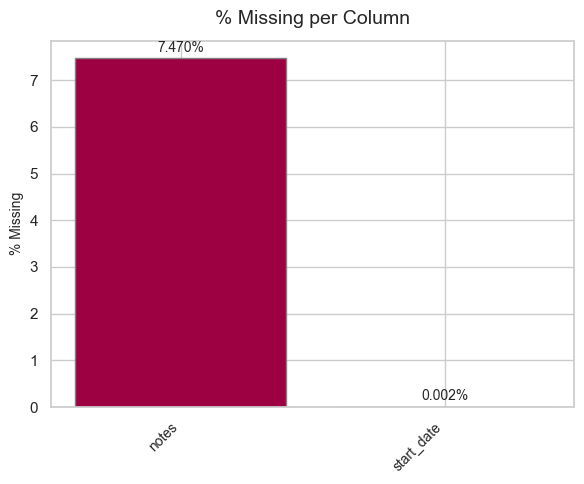

In [35]:
# Prepare data.
original_cols = pd.Index(
    [
        "id",
        "title",
        "description",
        "tags",
        "last_updated",
        "units",
        "frequency",
        "seasonal_adjustment",
        "notes",
        "categories",
        "data_source",
        "start_date",
        "end_date",
    ]
)
miss = fred[original_cols].isna().mean() * 100
miss = miss[miss > 0].sort_values(ascending=False)
# Plot.
plot_top_n_annotated_bar(
    counts=miss,
    total=100,
    top_n=len(miss),
    wrap_width=30,
    figsize=(max(6, len(miss) * 1.2), 5),
    dpi=100,
    xlabel="",
    ylabel="% Missing",
    title="% Missing per Column",
    rotation=45,
    fontsize_title=14,
    fontsize_labels=10,
    fontsize_annotation=10,
    note_prefix="",
    show_coverage_note=False,
    annotation_fmt="{pct:.3f}%",
)

Aside from the optional notes field, the dataset has got essentially full coverage across all other metadata columns—so downstream analyses won’t be materially impacted by missing values.

<a name='descriptor-analytics'></a>
### Descriptor Analytics

(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Notes Length Distribution'}, xlabel='Length (characters)', ylabel='Count'>)

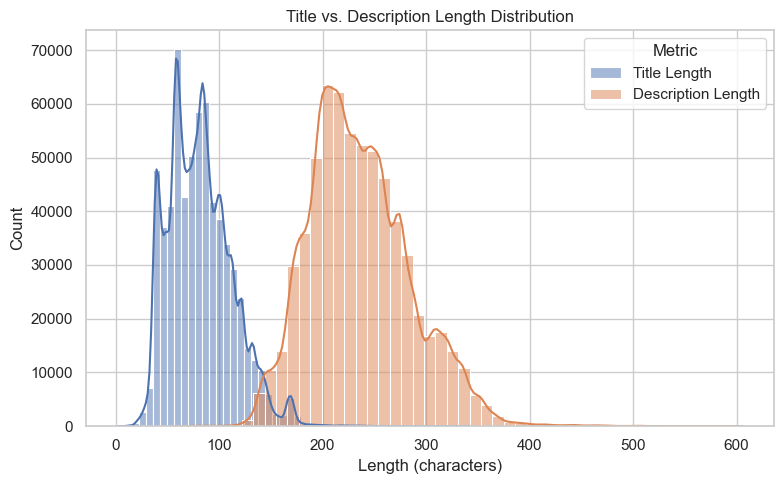

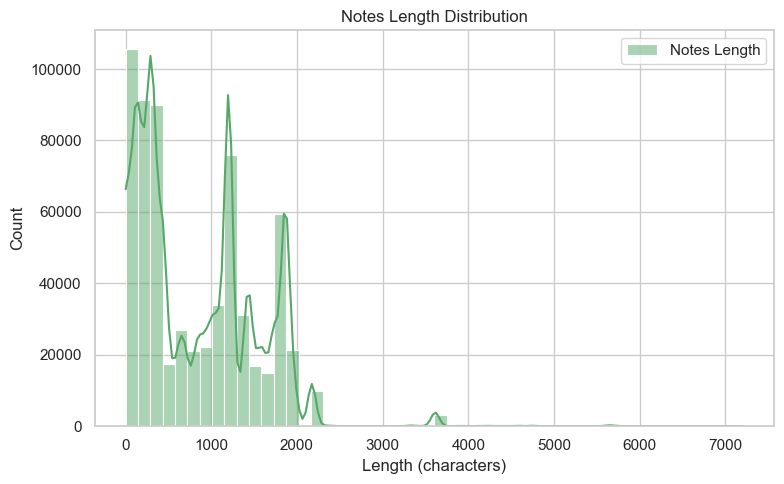

In [36]:


# Plot title and description lengths together.
plot_histograms(
    data_series=[fred["title_len"], fred["desc_len"]],
    labels=["Title Length", "Description Length"],
    colors=["C0", "C1"],
    bins=50,
    kde=True,
    figsize=(8, 5),
    xlabel="Length (characters)",
    title="Title vs. Description Length Distribution",
    legend_title="Metric",
)
# Plot notes length separately.
plot_histograms(
    data_series=[fred["notes_len"]],
    labels=["Notes Length"],
    colors=["C2"],
    bins=50,
    kde=True,
    figsize=(8, 5),
    xlabel="Length (characters)",
    title="Notes Length Distribution",
    legend_title=None,
)


- **Titles are short and consistent:** Almost all series titles fall between **30–150 characters**, peaking around **70–100 chars**.

- **Descriptions are longer:** Descriptions peak in the **200-250 char** range, with a right‑skew into a **400+ char** tail.

- **Notes are highly variable:** Most notes stay under **2,000 chars**, but a significant number stretch into **multiple‑thousand‑char** territory; combined with ~**7.5% missingness**


<a name='top-data-sources'></a>
### Top Data Sources

(<Figure size 1400x600 with 1 Axes>,
 <Axes: title={'center': 'Top 20 Data Sources'}, xlabel='Data Source', ylabel='Series Count'>)

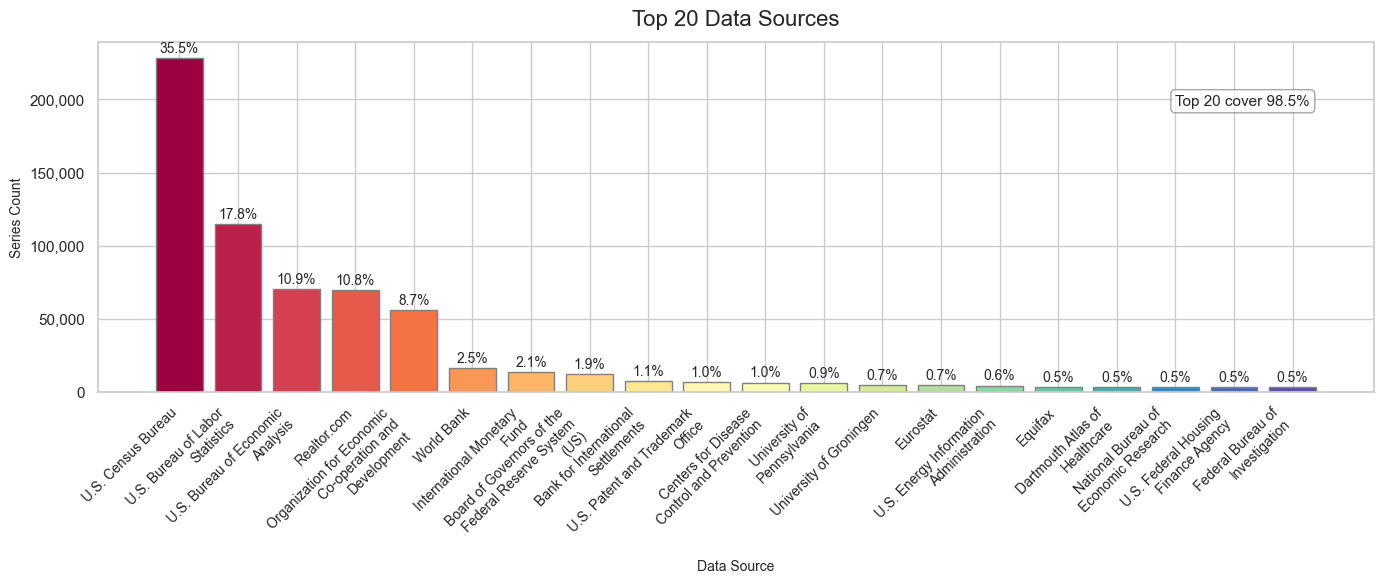

In [37]:
# Prepare data.
src_counts, total = prepare_top_counts(fred, "data_source", top_n=20)
# Plot.
plot_top_n_annotated_bar(
    counts=src_counts,
    total=total,
    top_n=20,
    wrap_width=25,
    figsize=(14, 6),
    dpi=100,
    xlabel="Data Source",
    ylabel="Series Count",
    title="Top 20 Data Sources",
    note_prefix="Top {n} cover ",
    note_pos=(0.95, 0.85),
    rotation=45,
    fontsize_title=16,
    fontsize_labels=10,
    fontsize_annotation=10,
    fontsize_note=11,
)

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Coverage vs Top 20 Data Sources'}, xlabel='Top N Data Sources', ylabel='Coverage (%)'>)

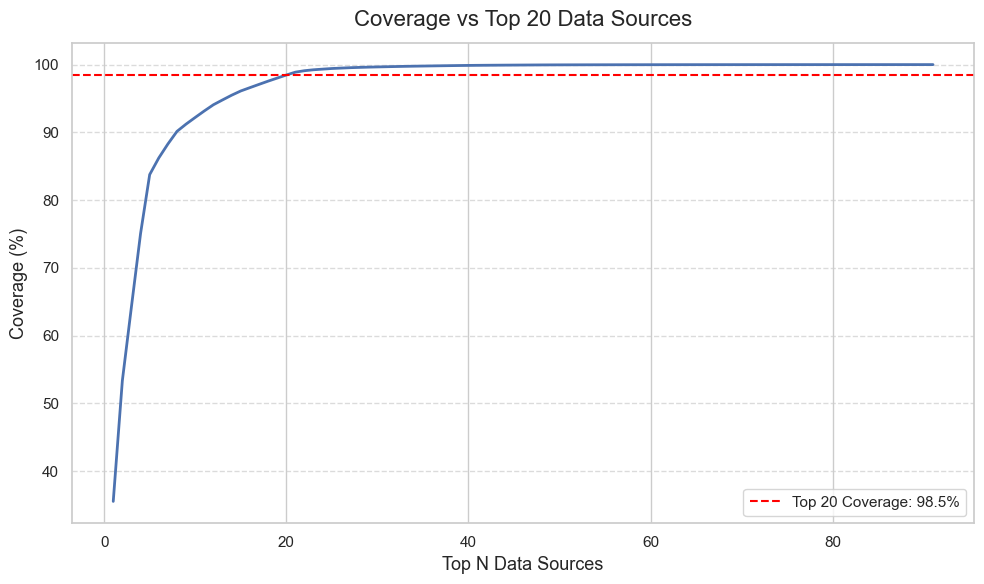

In [38]:
# Coverage.
# Prepare data.
src_counts = fred["data_source"].value_counts()
cum_src_coverage = (
    src_counts.sort_values(ascending=False).cumsum() / src_counts.sum() * 100
)
plot_cumulative_coverage(
    cum_coverage=cum_src_coverage,
    N=N,
    xlabel="Top N Data Sources",
    ylabel="Coverage (%)",
    title=f"Coverage vs Top {N} Data Sources",
)

- **U.S.‑centric dominance (Unsurprising)**
  The top two sources are both major U.S. agencies: the U.S. Census Bureau (~35.5% of all series) and the Bureau of Labor Statistics (~17.8%). Together they supply over half of the entire database.

- **Heavy skew toward a handful of providers**
  The top five sources (adding the Bureau of Economic Analysis, Realtor.com, and the World Bank) contribute nearly 80% of all series. Beyond those, each additional source accounts for less than 11%.

- **Long but very shallow tail**
  Although 20 sources are shown, after the first handful the individual shares quickly drop below 3% each—and the smallest still make up only about 0.5% apiece.

- **Top 20 cover almost the whole universe**
  These 20 providers account for about **98.5%** of every series in the metadata, meaning there are very few “minor” suppliers beyond this group.

<a name='data-freshness'></a>
## Data Freshness

In [39]:


def plot_cumulative_count(
    series,
    xlabel: str = "",
    ylabel: str = "",
    title: str = "",
    color: str = "steelblue",
    linewidth: float = 2,
    grid: bool = True,
    grid_alpha: float = 0.3,
    figsize: tuple = (10, 6),
    dpi: int = 100,
    fontsize_title: int = 14,
    fontsize_labels: int = 12,
):
    """
    Plot cumulative values of a Series as a line graph with grid and labels.

    :param series: the Series with a sortable index to plot
    :param xlabel: the label for the x-axis
    :param ylabel: the label for the y-axis
    :param title: the title of the plot
    :param color: the color of the line
    :param linewidth: the width of the line
    :param grid: flag to display grid lines
    :param grid_alpha: the transparency level for the grid
    :param figsize: the size of the figure
    :param dpi: the resolution of the figure
    :param fontsize_title: the font size for the title
    :param fontsize_labels: the font size for axis labels
    :return: the figure and axes of the plot
    """
    # Initialize figure.
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    # Plot series.
    ax.plot(series.index, series.values, color=color, linewidth=linewidth)
    if grid:
        # Enable grid.
        ax.grid(True, alpha=grid_alpha)
    ax.set_xlabel(xlabel, fontsize=fontsize_labels)
    ax.set_ylabel(ylabel, fontsize=fontsize_labels)
    ax.set_title(title, fontsize=fontsize_title, pad=12)
    # Adjust layout.
    plt.tight_layout()
    return fig, ax

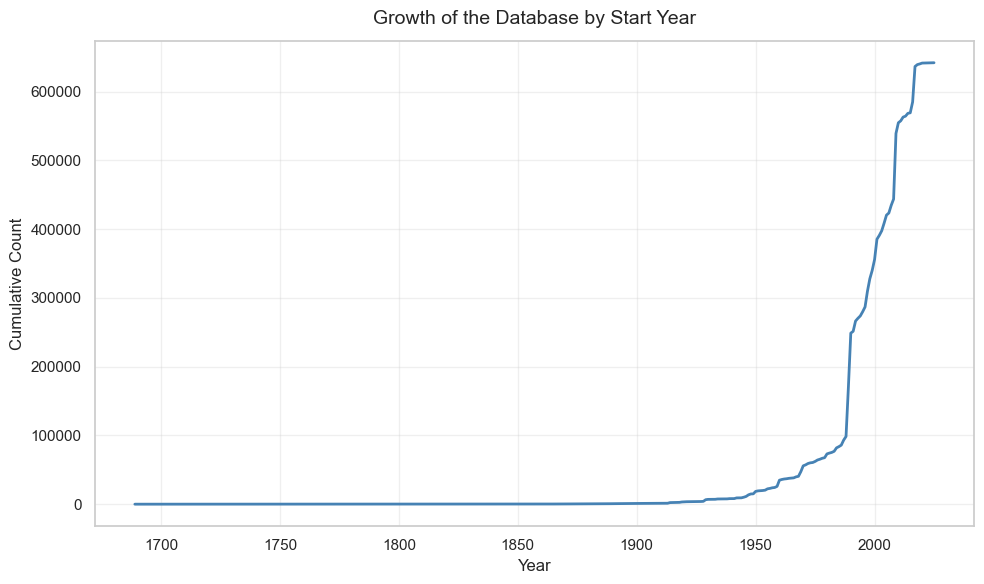

In [40]:
# Prepare data.
cum = fred.groupby("start_year").size().sort_index().cumsum()
# Plot.
plot_cumulative_count(
    cum,
    xlabel="Year",
    ylabel="Cumulative Count",
    title="Growth of the Database by Start Year",
    color="steelblue",
    linewidth=2,
    grid_alpha=0.3,
    fontsize_title=14,
    fontsize_labels=12,
)
plt.show()

- **Slow beginnings:** Very little data from 1700 through roughly 1950 were added.
- **Mid‑century pickup:** Between 1950 and 1980 there’s a steady climb, reflecting growing data collection efforts in history.
- **Digital‐era explosion:** After 1980 the curve steepens, and especially post‑2000 it shoots up to over 600 000 series—driven by electronic data releases, globalization of sources, and API availability. The dataset’s breadth is overwhelmingly a product of recent decades; most series are relatively “young.”

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'Days Since Last Update'}, xlabel='Staleness (days)', ylabel='Count'>)

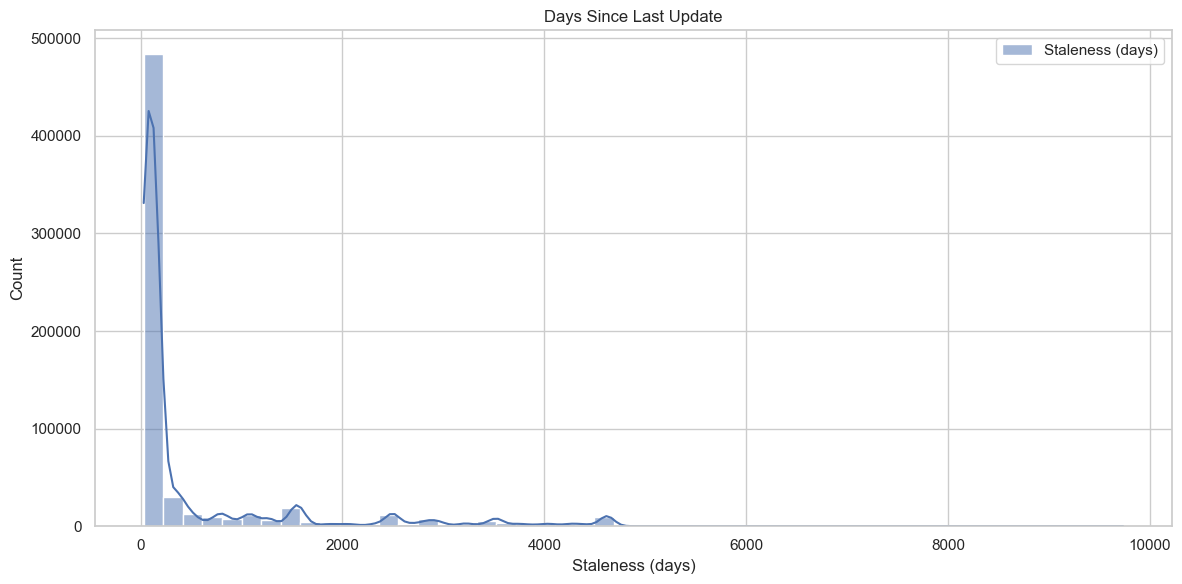

In [41]:
# Plot staleness by days.
# Prepare data.
plot_histograms(
    data_series=[fred["staleness_days"]],
    labels=["Staleness (days)"],
    colors=["C0"],
    bins=50,
    kde=True,
    figsize=(12, 6),
    xlabel="Staleness (days)",
    title="Days Since Last Update",
    legend_title=None,
)

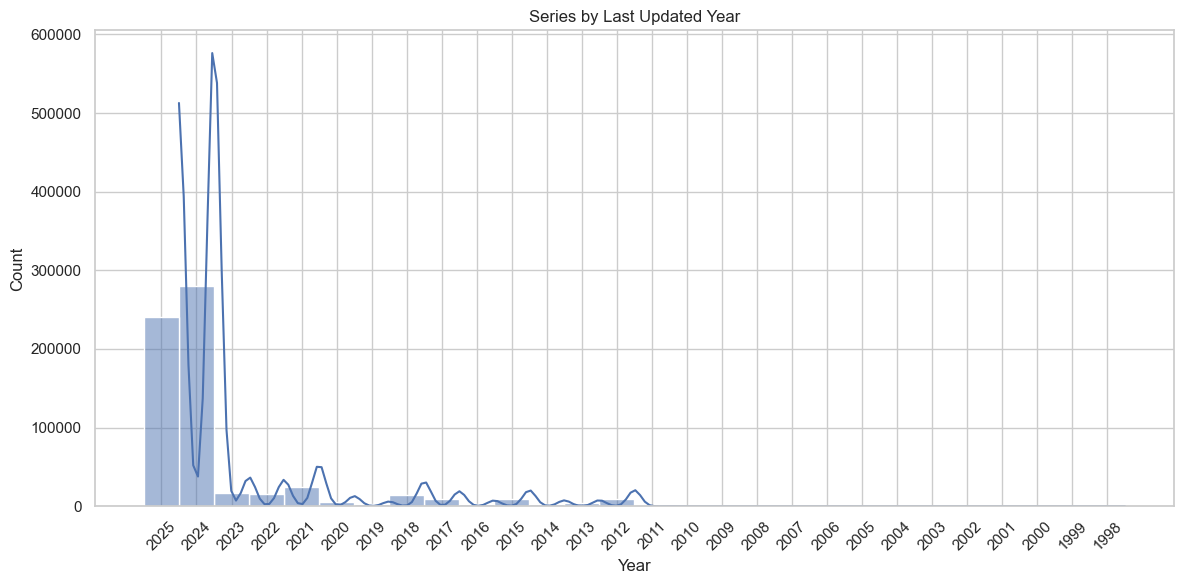

In [42]:
def prepare_last_year_data(fred: pd.DataFrame) -> Tuple:
    """
    Extract last updated years and compute histogram bins and tick marks.

    :param fred: relevant data
    :return: filtered year series, bin edges for each year, and ticks
        for each year
    """
    years_series = fred["last_year"].dropna().astype(int)
    year_min, year_max = years_series.min(), years_series.max()
    bin_edges = np.arange(year_min, year_max + 2)
    ticks = np.arange(year_min, year_max + 1, 1)
    return years_series, bin_edges, ticks


# Prepare data.
years_series, bin_edges, ticks = prepare_last_year_data(fred)
# Plot.
fig, ax = plot_histograms(
    data_series=[years_series],
    labels=[""],
    colors=["C0"],
    bins=bin_edges,
    kde=True,
    figsize=(12, 6),
    xlabel="Year",
    title="Series by Last Updated Year",
    legend_title=None,
    xticks=ticks,
    xtick_labels=ticks,
    xticks_shift=0.5,
    xticks_rotation=45,
    invert_xaxis=True,
)
plt.show()


- **Fresh majority:** A huge spike near zero days indicates that most series are updated very recently (e.g. within weeks or months).
- **Heavy tail:** There are a long tail of series with thousands of days since last update—these are largely discontinued or legacy series.
- **But most data remain current, validating FRED as a live data source.**



<a name='start/end-cohorts-by-decade'></a>
### Start/End Cohorts by Decade

In [43]:
def plot_grouped_bars(
    df: pd.DataFrame,
    categories: list[str],
    series_names: list[str],
    colors: list[str],
    *,
    xlabel: str = "",
    ylabel: str = "",
    title: str = "",
    bar_width: float = 0.4,
    annotation_fmt: str = "{pct:.1f}%",
    fontsize_title: int = 15,
    fontsize_labels: int = 13,
    fontsize_annotation: int = 9,
    grid: bool = True,
    grid_kwargs: dict = None,
    figsize: tuple = (10, 5),
    dpi: int = 100,
    legend_title: str = None,
):
    """
    Plot multiple series side by side for each category.

    :param df: source for series counts
    :param categories: category labels for x-axis
    :param series_names: series names to plot
    :param colors: color codes for series
    :return: figure and axes
    """
    # Compute x positions.
    x = np.arange(len(categories))
    # Create figure and axes.
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    # Compute number of series.
    n = len(series_names)
    # Loop through each series.
    for i, (name, color) in enumerate(zip(series_names, colors)):
        vals = df[name].loc[categories].values
        offset = (i - (n - 1) / 2) * bar_width
        bars = ax.bar(
            x + offset,
            vals,
            width=bar_width,
            label=name,
            color=color,
            edgecolor="white",
        )
        # Annotate bars.
        maxval = df.values.max()
        for b, v in zip(bars, vals):
            pct = v / df[series_names].values.sum() * 100
            txt = annotation_fmt.format(pct=pct)
            ax.text(
                b.get_x() + b.get_width() / 2,
                v + maxval * 0.005,
                txt,
                ha="center",
                va="bottom",
                fontsize=fontsize_annotation,
            )
    ax.set_xticks(x)
    ax.set_xticklabels(categories, fontsize=fontsize_labels)
    ax.set_xlabel(xlabel, fontsize=fontsize_labels)
    ax.set_ylabel(ylabel, fontsize=fontsize_labels)
    ax.set_title(title, fontsize=fontsize_title, pad=12)
    if legend_title or series_names:
        ax.legend(title=legend_title)
    if grid:
        ax.grid(axis="y", **(grid_kwargs or {"linestyle": "--", "alpha": 0.7}))
    plt.tight_layout()
    return fig, ax

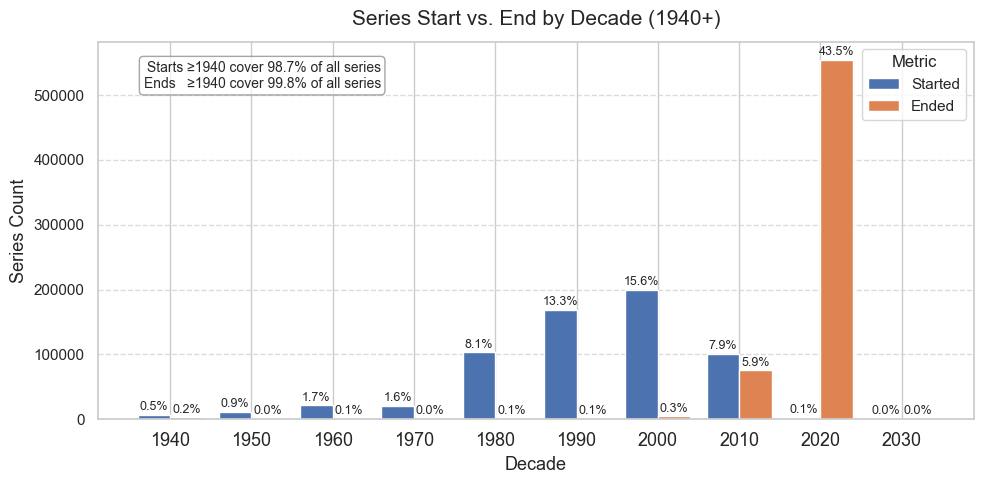

In [44]:
# Prepare Data.
start_counts = fred["start_decade"].value_counts().sort_index()
end_counts = fred["end_decade"].value_counts().sort_index()
df_decade = (
    pd.DataFrame({"Started": start_counts, "Ended": end_counts})
    .fillna(0)
    .astype(int)
)

# Filter to >=1940.
df_plot = df_decade.loc[df_decade.index >= 1940]
categories = df_plot.index.astype(int).tolist()
# Plot.
plot_grouped_bars(
    df=df_plot,
    categories=categories,
    series_names=["Started", "Ended"],
    colors=["C0", "C1"],
    xlabel="Decade",
    ylabel="Series Count",
    title="Series Start vs. End by Decade (1940+)",
    legend_title="Metric",
    bar_width=0.4,
    annotation_fmt="{pct:.1f}%",
    figsize=(10, 5),
    dpi=100,
)
# Coverage.
total_started = df_decade["Started"].sum()
total_ended = df_decade["Ended"].sum()
pct_s = df_plot["Started"].sum() / total_started * 100
pct_e = df_plot["Ended"].sum() / total_ended * 100
plt.gca().text(
    0.323,
    0.95,
    f"Starts ≥1940 cover {pct_s:.1f}% of all series\n"
    f"Ends   ≥1940 cover {pct_e:.1f}% of all series",
    transform=plt.gca().transAxes,
    ha="right",
    va="top",
    fontsize=10,
    bbox={"boxstyle": "round,pad=0.3", "fc": "white", "ec": "gray", "alpha": 0.7},
)
plt.show()

(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'Series with End Date After Today'}, ylabel='Series Count'>)

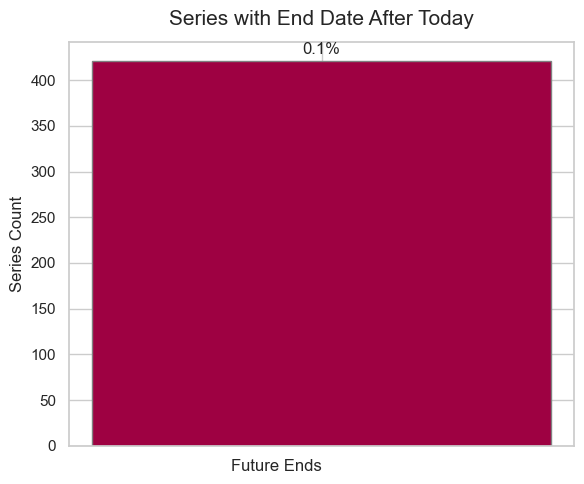

In [46]:
# Prepare data.
today = pd.Timestamp.today().normalize()
future_ends = (fred["end_date"] > today).sum()
total_series = len(fred)
# Plot.
plot_top_n_annotated_bar(
    counts=pd.Series({"Future Ends": future_ends}),
    total=total_series,
    top_n=1,
    wrap_width=None,  # no wrapping needed for single label
    figsize=(6, 5),
    dpi=100,
    xlabel="",  # no x-label
    ylabel="Series Count",
    title="Series with End Date After Today",
    rotation=0,  # vertical label
    fontsize_title=15,
    fontsize_labels=12,
    fontsize_annotation=12,
    formatter=FuncFormatter(lambda y, pos: f"{int(y):,}"),
    show_coverage_note=False,  # omit "Top N cover…" note
)

- **Modern‐Era Focus**
  Over 98% of all series began in 1940 or later, and nearly 75% started between 1980 and 2000, reflecting FRED’s rapid expansion in recent decades.

- **Peak Series Introductions**
  The 2000s saw the highest share of new series (≈31%), followed by the 1990s (≈26%). Earlier decades (1940–1970) each contributed only 1–3%.

- **Tapering New Additions**
  After 2000, the rate of new series slows: the 2010s account for ≈16%, and the 2020s almost none (<1%), suggesting FRED has matured.

- **End‐Date Concentration**
  End dates cluster overwhelmingly in the 2020s (≈86%), indicating most series remain active up through data collected in 2020.

- **Ongoing Data Availability**
  The spike in 2020 end dates implies that the vast majority of series are still maintained beyond that year; very few series have truly “ended.”

<a name='discontinued-series'></a>
### Discontinued Series

(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'Active vs. Discontinued Series'}>)

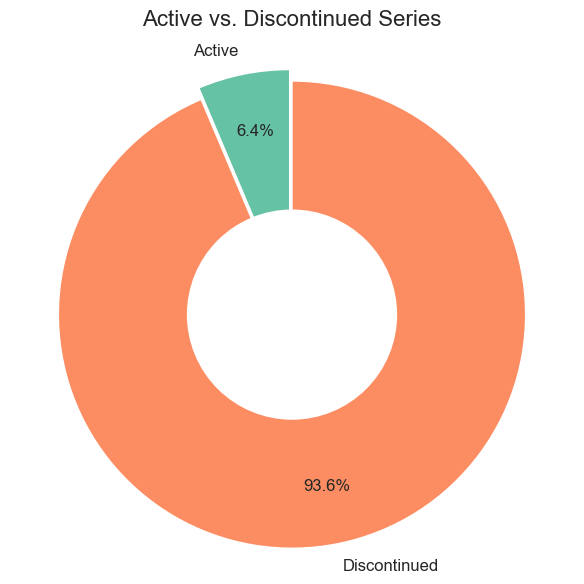

In [47]:
# Prepare data.
labels, sizes = get_binary_counts(
    fred, mask=fred["is_discontinued"], labels=["Active", "Discontinued"]
)
# Plot.
plot_donut(sizes=sizes, labels=labels, title="Active vs. Discontinued Series")

<a name='active/discontinued-by-source'></a>
### Active/Discontinued by Source

(<Figure size 1400x600 with 1 Axes>,
 <Axes: title={'center': 'Active vs. Discontinued by Data Source'}, xlabel='Data Source', ylabel='Series Count'>)

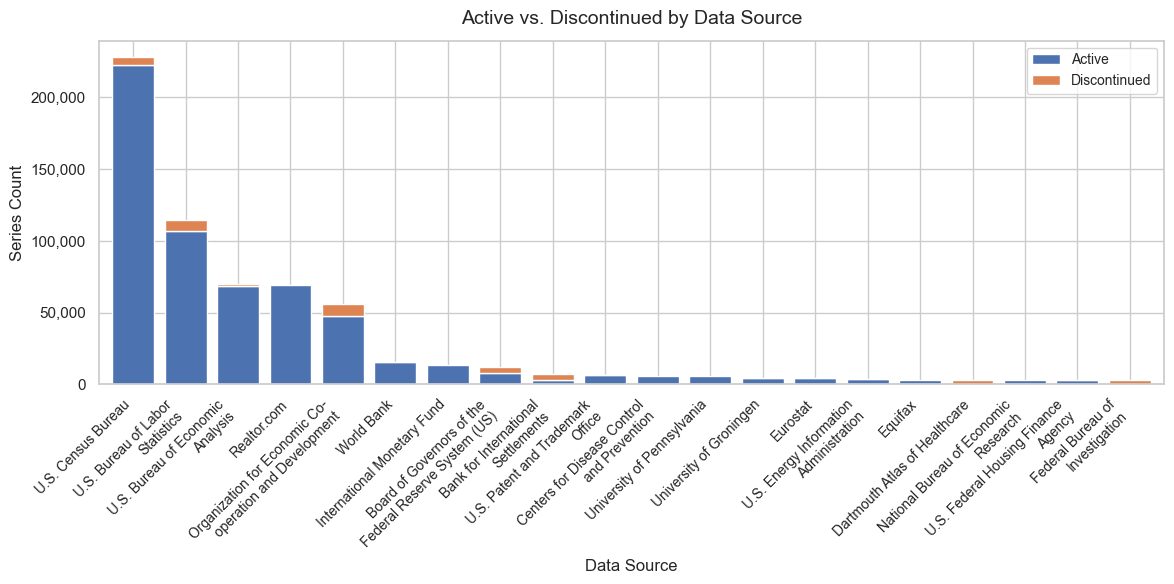

In [48]:
# Prepare data.
ds_top20, labels = prepare_crosstab(
    fred,
    index_col="data_source",
    pivot_col="is_discontinued",
    top_n=20,
    wrap_width=30,
)
# Plot.
plot_stacked_bar(
    df=ds_top20,
    index_labels=labels,
    xlabel="Data Source",
    ylabel="Series Count",
    title="Active vs. Discontinued by Data Source",
    legend_labels=["Active", "Discontinued"],
    colormap=["C0", "C1"],
)

(<Figure size 1400x600 with 1 Axes>,
 <Axes: title={'center': 'Active vs. Discontinued (Non-Dominant Sources)'}, xlabel='Data Source', ylabel='Series Count'>)

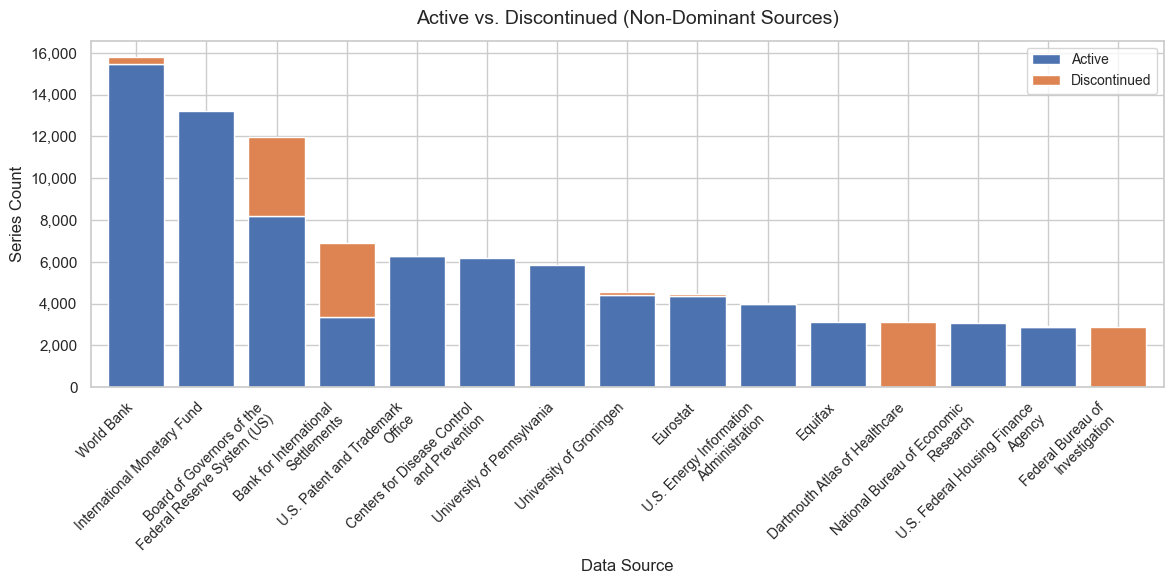

In [49]:
# Prepare data.
nd = ds_top20.index[5:]
ds_nd, labels_nd = prepare_crosstab(
    fred,
    index_col="data_source",
    pivot_col="is_discontinued",
    index_list=nd,
    wrap_width=30,
)
# Plot.
plot_stacked_bar(
    df=ds_nd,
    index_labels=labels_nd,
    xlabel="Data Source",
    ylabel="Series Count",
    title="Active vs. Discontinued (Non-Dominant Sources)",
    legend_labels=["Active", "Discontinued"],
    colormap=["C0", "C1"],
)

<a name='top-20-discontinued-by-data-source'></a>
### Top 20 Discontinued by Data Source

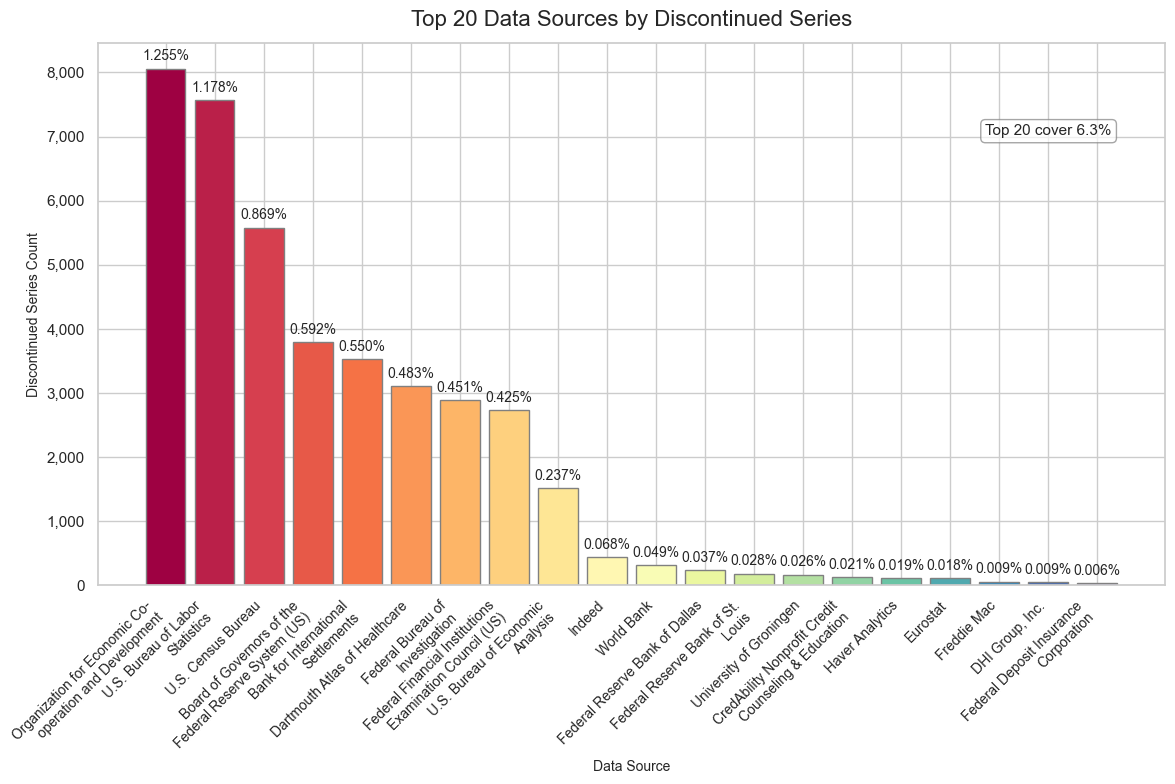

In [50]:
# Prepare data.
disc_src, _ = prepare_top_counts(
    fred, "data_source", filter_mask=fred["is_discontinued"], top_n=20
)
# Plot with our reusable function.
fig, ax = plot_top_n_annotated_bar(
    counts=disc_src,
    total=total,
    top_n=20,
    wrap_width=30,
    figsize=(12, 8),
    dpi=100,
    xlabel="Data Source",
    ylabel="Discontinued Series Count",
    title=f"Top {20} Data Sources by Discontinued Series",
    rotation=45,
    annotation_fmt="{pct:.3f}%",
    show_coverage_note=True,
)
plt.show()

<a name='top-20-discontinued-by-tag'></a>
### Top 20 Discontinued by Tag

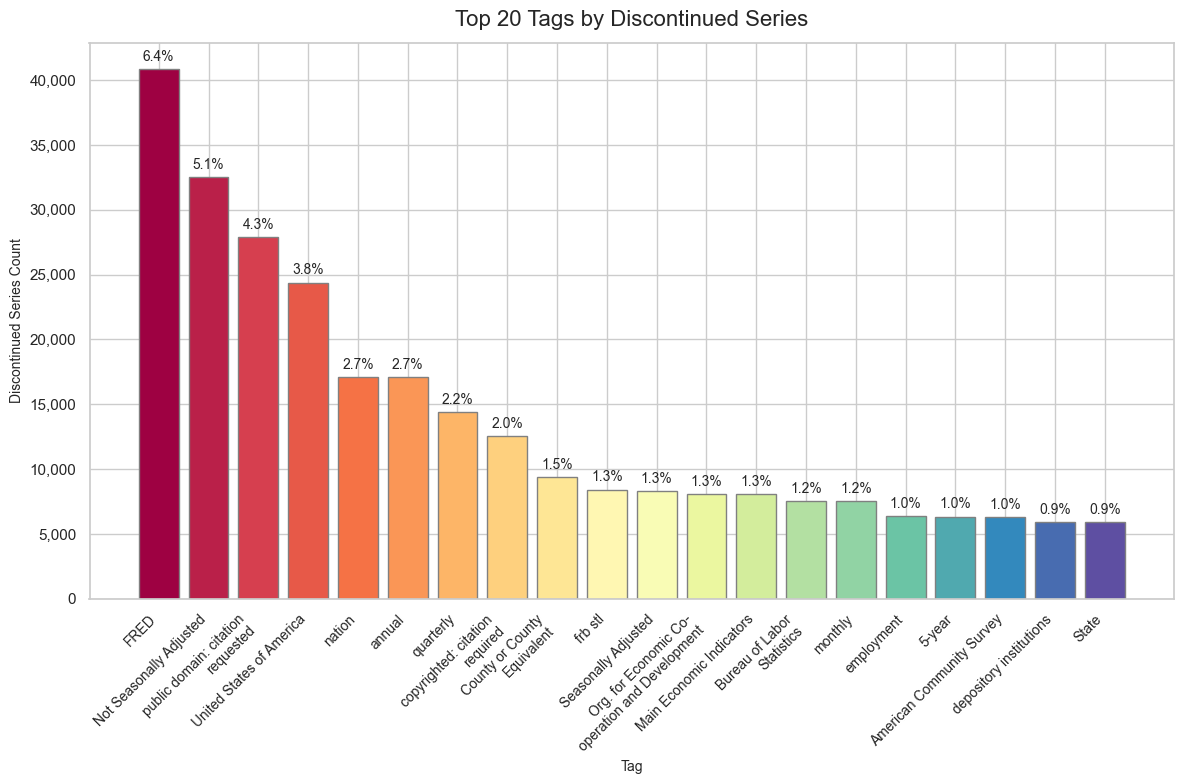

In [51]:
# Prepare data.
disc_tags, _ = prepare_top_counts(
    fred,
    "tags_list",
    filter_mask=fred["is_discontinued"],
    explode=True,
    # Drop duplicate tags that show up in the plot.
    drop=[
        "discontinued",
        "federal reserve",
        "fred",
        "nsa",
        "usa",
        "county",
        "bls",
        "acs",
        "St. Louis Fed",
        "mei",
        "oecd",
        "sa",
        "Federal Reserve",
        "Economic Data",
    ],
    top_n=20,
)
# Plot using our reusable function.
fig, ax = plot_top_n_annotated_bar(
    counts=disc_tags,
    total=total,
    top_n=N,
    wrap_width=25,
    figsize=(12, 8),
    dpi=100,
    xlabel="Tag",
    ylabel="Discontinued Series Count",
    title=f"Top {N} Tags by Discontinued Series",
    rotation=45,
    fontsize_title=16,
    fontsize_labels=10,
    fontsize_annotation=10,
    fontsize_note=11,
    formatter=FuncFormatter(lambda y, pos: f"{int(y):,}"),
    note_prefix=f"Top {N} appear in ",
    show_coverage_note=False,
)

plt.tight_layout()
plt.show()

<a name='top-20-discontinued-by-category'></a>
### Top 20 Discontinued by Category

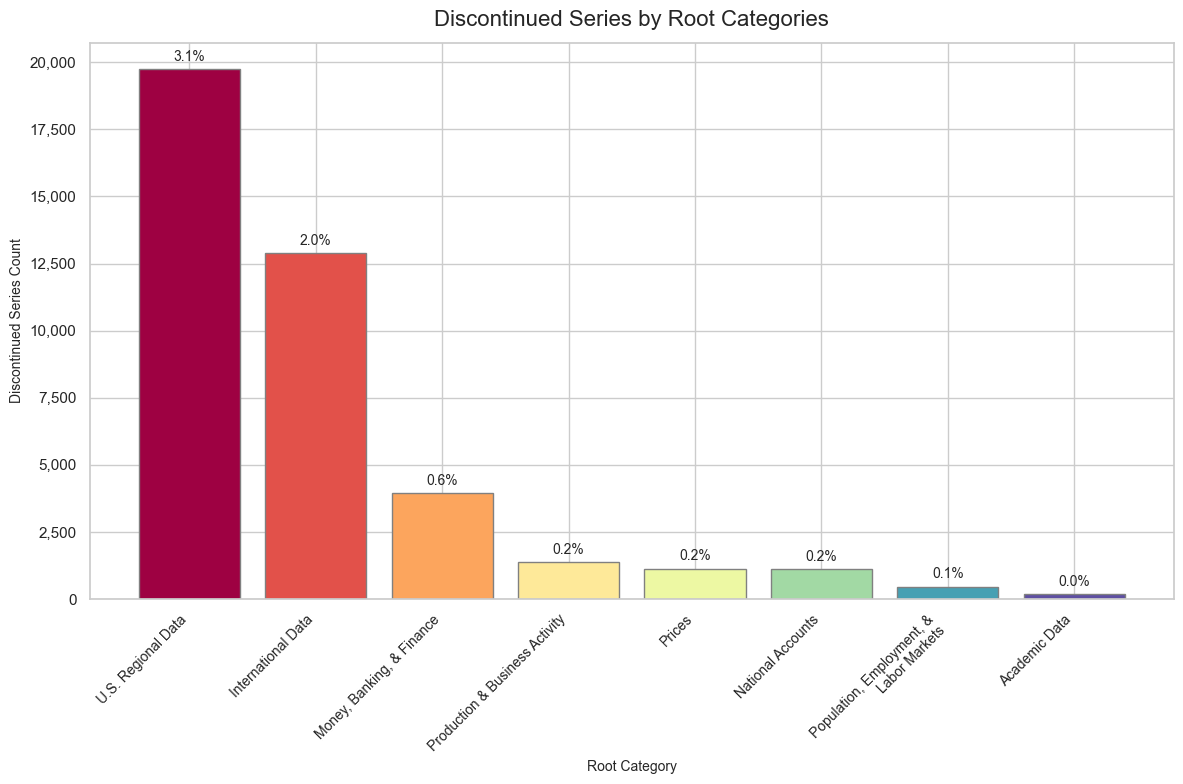

In [52]:

# Prepare data: Root Categories.
disc_root, _ = prepare_top_counts(
    fred,
    "categories",
    filter_mask=fred["is_discontinued"],
    split=(";", 0),  # root
    top_n=20,
)
# Plot.
fig, ax = plot_top_n_annotated_bar(
    counts=disc_root,
    total=total,
    top_n=N,
    wrap_width=30,
    figsize=(12, 8),
    dpi=100,
    xlabel="Root Category",
    ylabel="Discontinued Series Count",
    title="Discontinued Series by Root Categories",
    rotation=45,
    fontsize_title=16,
    fontsize_labels=10,
    fontsize_annotation=10,
    fontsize_note=11,
    formatter=FuncFormatter(lambda y, pos: f"{int(y):,}"),
    note_prefix=f"Top {N} cover ",
    show_coverage_note=False,
)
plt.tight_layout()
plt.show()

**Active vs. Discontinued Series**
- 93.6% of all time series are discontinued
- Only 6.4% remain active

**Active vs. Discontinued by Data Source**
- The U.S. Census Bureau leads with ~220 k active and a small discontinued tail
- The Bureau of Labor Statistics and BEA follow with ~105 k and ~70 k active respectively
- Discontinuations are minimal among the largest sources (<5% of each source’s total)

**Active vs. Discontinued (Non-Dominant Sources)**
- World Bank (~15.4 k active) and IMF (~13.2 k active) show relatively few discontinued series
- Board of Governors of the Federal Reserve System and Bank for International Settlements each have ~8 k active vs ~4 k discontinued
- Dartmouth Atlas of Healthcare and Federal Bureau of Investigation series are almost exclusively discontinued

**Top 20 Data Sources by Discontinued Series**
- OECD (Organization for Economic Cooperation and Development) has the highest discontinued count (~8 k, 1.26%)
- BLS (~7.5 k, 1.18%) and U.S. Census Bureau (~5.6 k, 0.87%) round out the top three
- The top 20 sources account for just 6.3% of all discontinued series

**Top 20 Tags by Discontinued Series**
- “FRED” appears on 6.4% of discontinued series
- “Not Seasonally Adjusted” (5.1%), “public domain: citation requested” (4.3%) and “United States of America” (3.8%) are the next most common tags
- Frequency tags like “annual” and “quarterly” each cover ~2.7% of discontinued series

**Discontinued Series by Root Categories**
- U.S. Regional Data dominates discontinuations (~19.8 k, 3.1%)
- International Data is second (~12.9 k, 2.0%)
- Money, Banking & Finance (~3.9 k, 0.6%) and other categories are far less represented


<a name='frequency-of-data'></a>
### Frequency of Data

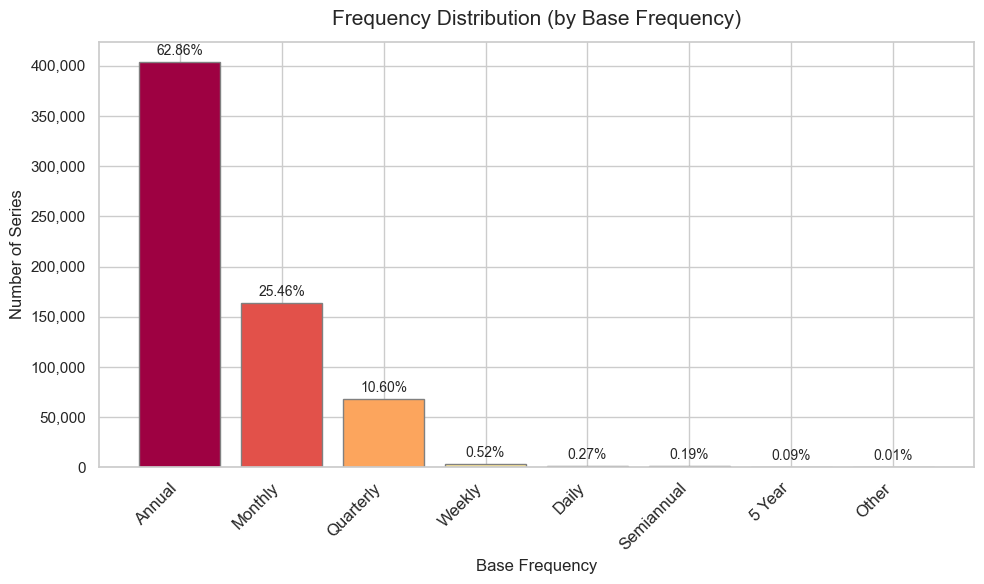

In [53]:
# Prepare Data.
freq_counts, _ = prepare_top_counts(
    fred,
    "freq_base",
    threshold=100,  # everything <100 → 'Other'
    include_other=False,
)
# Plot.
plot_top_n_annotated_bar(
    counts=freq_counts,
    total=total,
    top_n=len(freq_counts),
    wrap_width=25,  # wrap long labels
    figsize=(10, 6),
    dpi=100,
    xlabel="Base Frequency",
    ylabel="Number of Series",
    title="Frequency Distribution (by Base Frequency)",
    rotation=45,
    fontsize_title=15,
    fontsize_labels=12,
    fontsize_annotation=10,
    formatter=FuncFormatter(lambda y, pos: f"{int(y):,}"),
    show_coverage_note=False,  # omit coverage note
    annotation_fmt="{pct:.2f}%",
)
plt.tight_layout()
plt.show()

<a name='base-frequency-by-data-source'></a>
### Base Frequency by Data Source

(<Figure size 1400x600 with 1 Axes>,
 <Axes: title={'center': 'Data Source vs. Base Frequency (Top 20)'}, xlabel='Data Source', ylabel='Series Count'>)

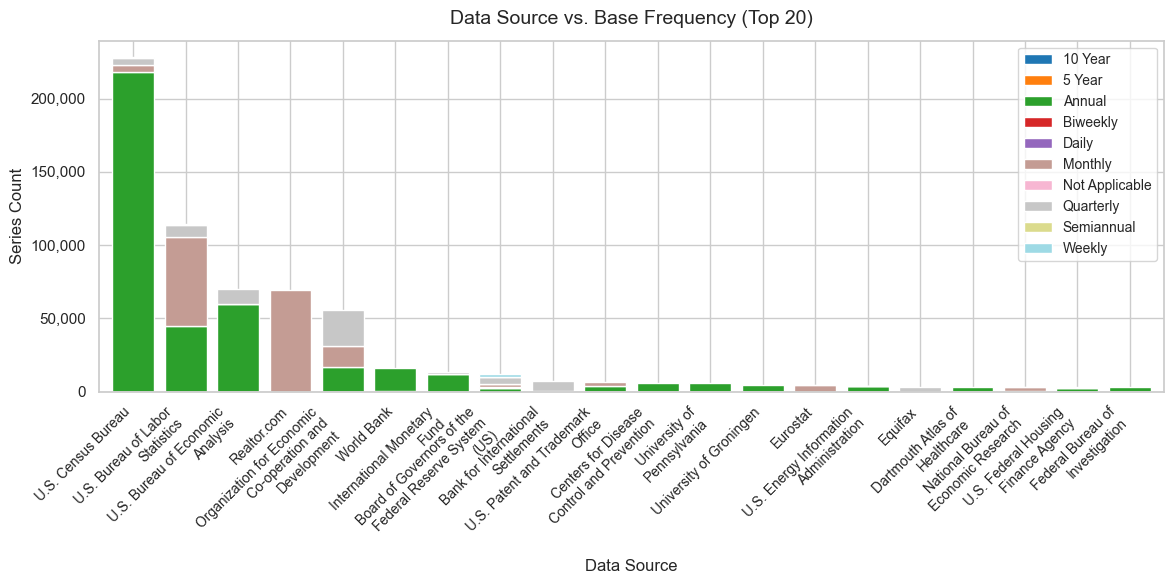

In [54]:
# Prepare data.
ct, labels = prepare_crosstab(
    fred, index_col="data_source", pivot_col="freq_base", top_n=20, wrap_width=25
)
# Plot.
plot_stacked_bar(
    df=ct,
    index_labels=labels,
    xlabel="Data Source",
    ylabel="Series Count",
    title="Data Source vs. Base Frequency (Top 20)",
    legend_labels=ct.columns.tolist(),
    colormap="tab20",
    width=0.8,
)

(<Figure size 1400x600 with 1 Axes>,
 <Axes: title={'center': 'Data Source vs. Non-Dominant Base Frequencies'}, xlabel='Data Source', ylabel='Series Count'>)

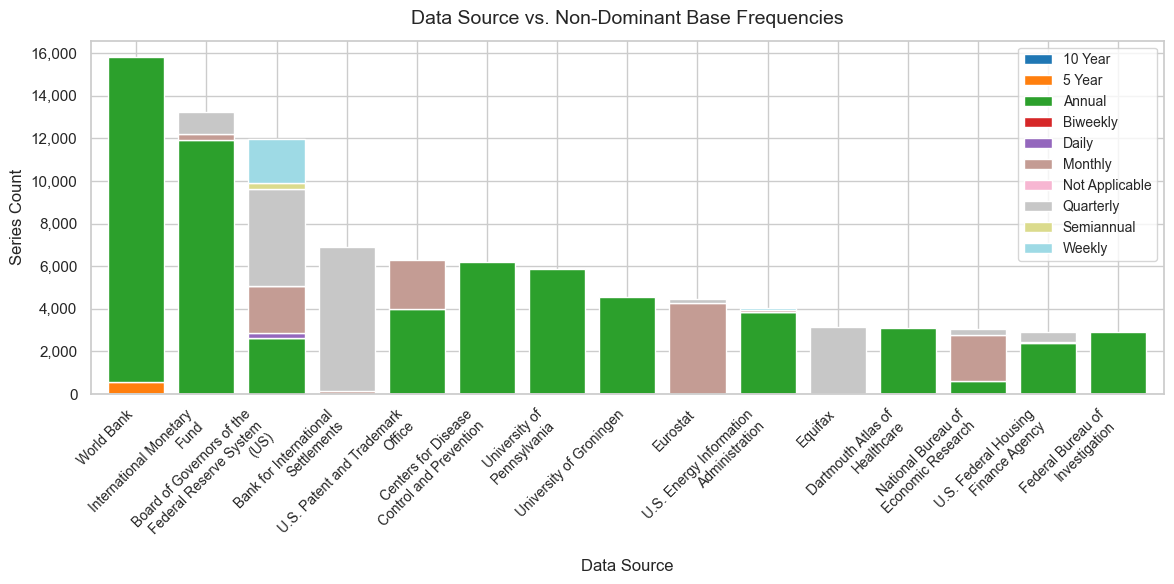

In [55]:
# Prepare data.
top20 = fred["data_source"].value_counts().head(20).index.tolist()
nd15 = top20[5:]
ct_nd, labels_nd15 = prepare_crosstab(
    fred,
    index_col="data_source",
    pivot_col="freq_base",
    index_list=nd15,
    wrap_width=25,
)
# Plot.
plot_stacked_bar(
    df=ct_nd,
    index_labels=labels_nd15,
    xlabel="Data Source",
    ylabel="Series Count",
    title="Data Source vs. Non-Dominant Base Frequencies",
    legend_labels=ct_nd.columns.tolist(),
    colormap="tab20",
    width=0.8,
)

- **Annual, Monthly & Quarterly dominate**
  The full distribution shows that Annual series account for **62.9%** of all data, Monthly for **25.5%**, and Quarterly for **10.6%**, together covering nearly **99%** of the database.

- **Minor frequencies are vanishingly rare**
  Even when grouping all other types (“Weekly”, “Daily”, “Semiannual”, “5 Year” and “Other”) into a single “Other” bucket, they collectively contribute less than **1%** of the total.

- **Zooming in on the non‑dominant slice**
  Removing Annual and Monthly leaves Weekly as the largest of the remainder at **0.52%**, followed by Daily (**0.27%**), Semiannual (**0.19%**), 5 Year (**0.09%**), and Other (**0.01%**).

- **Long‑tail nature of FRED frequencies**
  A tiny handful of base frequencies drive almost the entire series count, with the remaining frequencies forming a very flat, long tail that individually represent only fractions of a percent.


<a name='seasonal-adjustment-analysis'></a>
## Seasonal Adjustment Analysis

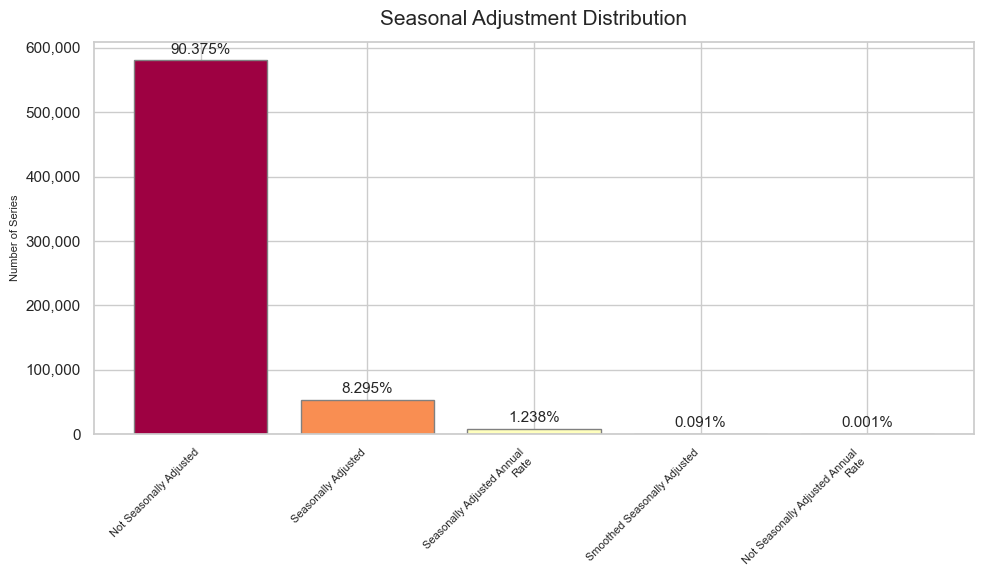

In [57]:
# Prepare data.
sa_counts, _ = prepare_top_counts(fred, "seasonal_adjustment", top_n=None)
# Plot.
plot_top_n_annotated_bar(
    counts=sa_counts,
    total=total,
    top_n=len(sa_counts),
    wrap_width=30,
    figsize=(10, 6),
    dpi=100,
    xlabel="",
    ylabel="Number of Series",
    title="Seasonal Adjustment Distribution",
    rotation=45,
    fontsize_title=15,
    fontsize_labels=8,
    fontsize_annotation=11,
    formatter=FuncFormatter(lambda y, pos: f"{int(y):,}"),
    show_coverage_note=False,
    annotation_fmt="{pct:.3f}%",
)
plt.tight_layout()
plt.show()

- **Overwhelming majority unadjusted** – about 90% of series are published “Not Seasonally Adjusted,” indicating raw data is the default for most indicators.
- **Seasonal adjustment still significant** – roughly 8% of series are adjusted for seasonal effects, reflecting key economic indicators (e.g., employment, inflation) where removing seasonal noise is critical.
- **Annual‐rate adjustments rare** – only about 1.2% use a “Seasonally Adjusted Annual Rate” format, and virtually none (<0.1%) employ smoothed or annual‐rate variants, suggesting specialized use cases.
- **Action point** – users seeking trend‐cleansed data will find a modest but not exhaustive selection of seasonally adjusted series; expanding adjustment coverage could benefit comparability across more datasets.

<a name='analyses-on-categories-and-tags'></a>
## Analyses on Categories and Tags

<a name='categories-distribution'></a>
### Categories Distribution

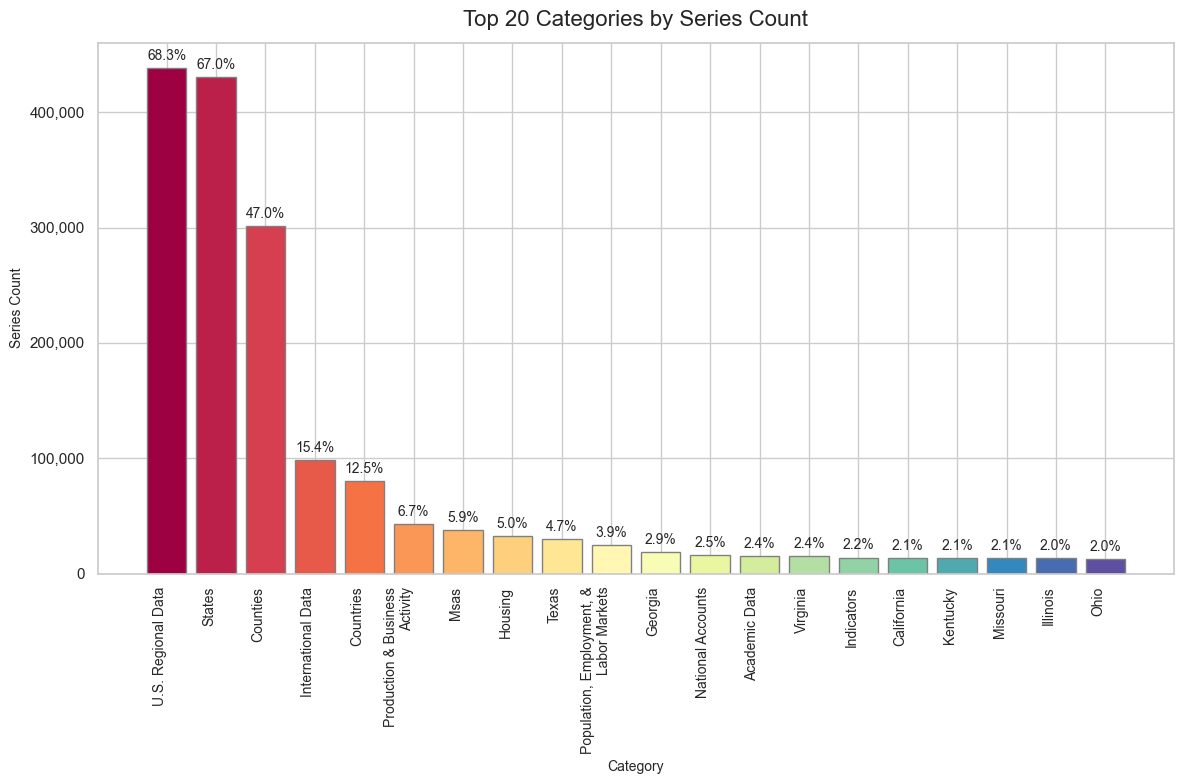

In [58]:
# Prepare Data.
cat_counts, _ = prepare_top_counts(
    fred, "categories_list", explode=True, top_n=20
)
# Plot.
plot_top_n_annotated_bar(
    counts=cat_counts,
    total=total,
    top_n=N,
    wrap_width=25,
    figsize=(12, 8),
    dpi=100,
    xlabel="Category",
    ylabel="Series Count",
    title=f"Top {N} Categories by Series Count",
    rotation=90,
    fontsize_title=16,
    fontsize_labels=10,
    fontsize_annotation=10,
    fontsize_note=11,
    formatter=FuncFormatter(lambda y, pos: f"{int(y):,}"),
    show_coverage_note=False,
)
plt.tight_layout()
plt.show()

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Coverage vs Top 20 Categories'}, xlabel='Top N Categories', ylabel='Coverage (%)'>)

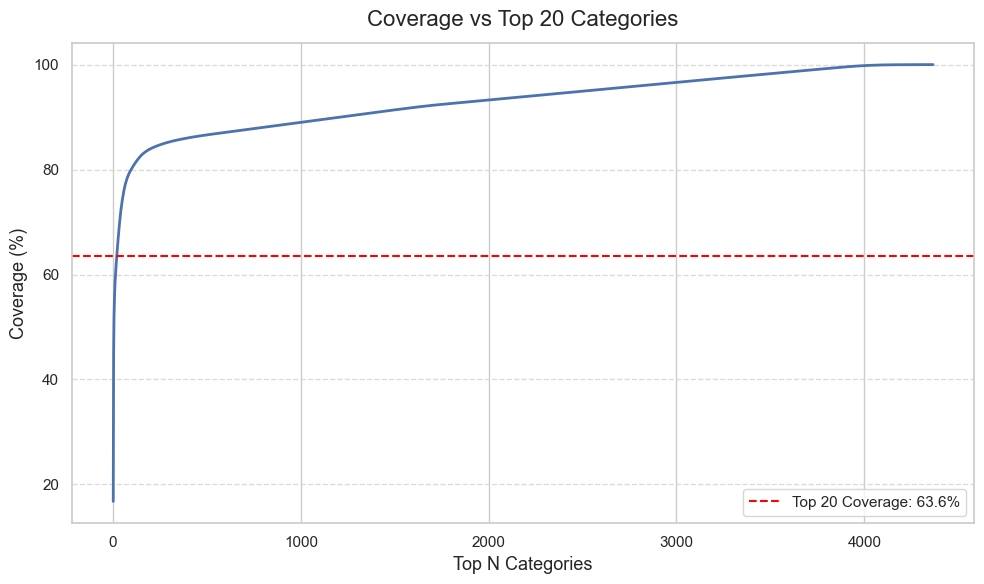

In [59]:
# Coverage vs Top 20 Categories.
# Prepare data.
cat_counts = fred["categories_list"].explode().value_counts()
cum_cat_coverage = (
    cat_counts.sort_values(ascending=False).cumsum() / cat_counts.sum() * 100
)
# Plot.
plot_cumulative_coverage(
    cum_coverage=cum_cat_coverage,
    N=N,
    xlabel="Top N Categories",
    ylabel="Coverage (%)",
    title=f"Coverage vs Top {N} Categories",
)

- **Highly concentrated**
  The top 20 categories account for roughly **63 %** of all category assignments.
  - The single largest category, **U.S. Regional Data**, alone represents nearly 17 % of all series.
  - The next two (**States** and **Counties**) each contribute over 11 %.

- **Long tail**
  Beyond the top 20, coverage climbs very slowly toward 100 % as you include more categories. Thousands of categories are needed before capturing the remaining ~37 % of assignments.

<a name='hierarchical-categorical-analyses'></a>
### Hierarchical Categorical Analyses

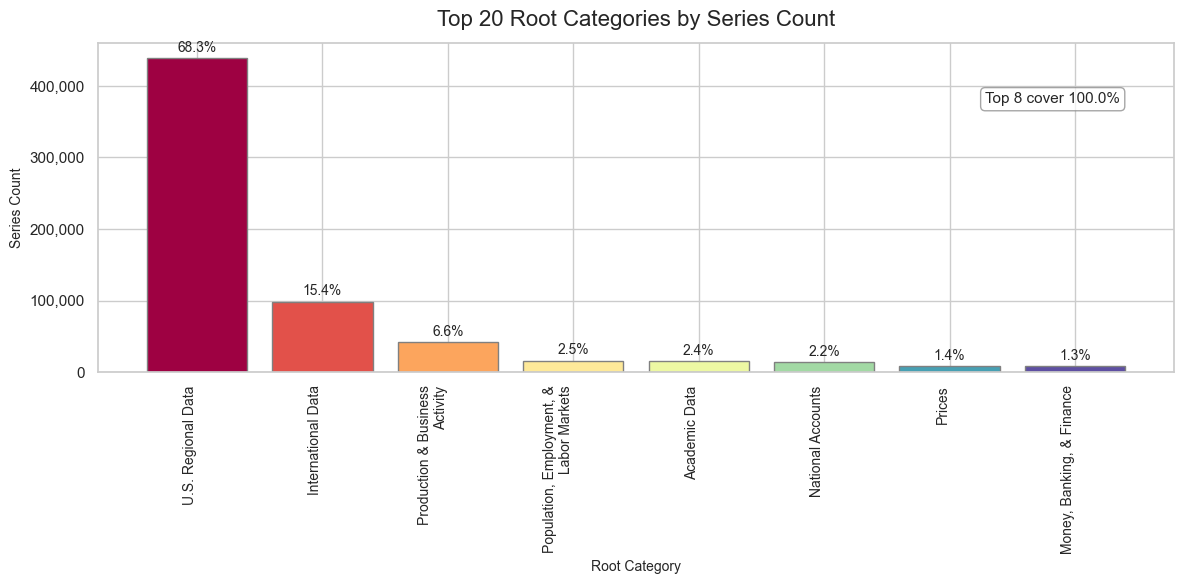

In [60]:
# Prepare data.
root_counts, total_series = prepare_top_counts(
    fred, "categories", split=(";", 0), top_n=20
)

# Plot.
plot_top_n_annotated_bar(
    counts=root_counts,
    total=total_series,
    top_n=8,
    wrap_width=25,  # wrap long names
    figsize=(12, 6),
    dpi=100,
    xlabel="Root Category",
    ylabel="Series Count",
    title="Top 20 Root Categories by Series Count",
    rotation=90,  # vertical x‐labels
    fontsize_title=16,
    fontsize_labels=10,
    fontsize_annotation=10,
    fontsize_note=11,
    formatter=FuncFormatter(lambda y, pos: f"{int(y):,}"),
)
plt.tight_layout()
plt.show()

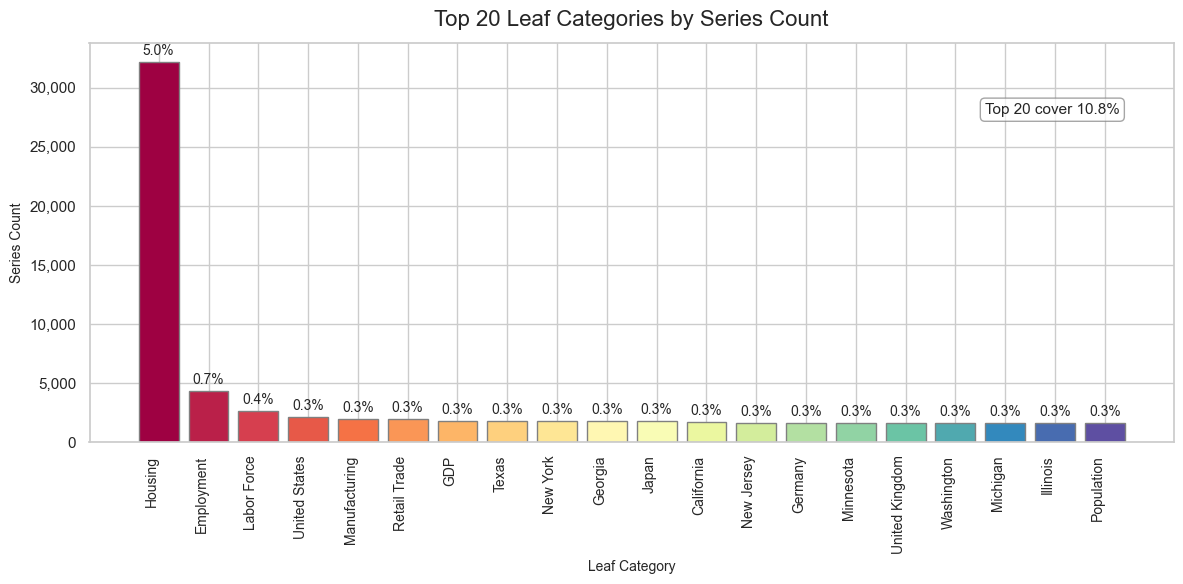

In [61]:
# Prepare data.
leaf_counts, total_series = prepare_top_counts(
    fred, "categories", split=(";", -1), top_n=20
)

# Plot.
plot_top_n_annotated_bar(
    counts=leaf_counts,
    total=total_series,
    top_n=20,
    wrap_width=25,  # wrap long leaf names
    figsize=(12, 6),
    dpi=100,
    xlabel="Leaf Category",
    ylabel="Series Count",
    title="Top 20 Leaf Categories by Series Count",
    rotation=90,  # vertical x‐labels
    fontsize_title=16,
    fontsize_labels=10,
    fontsize_annotation=10,
    fontsize_note=11,
    formatter=FuncFormatter(lambda y, pos: f"{int(y):,}"),
)
plt.tight_layout()
plt.show()

In [63]:


def build_category_hierarchy_counts(
    cat_series: pd.Series,
) -> Tuple[Counter, Dict[str, Counter], Dict[Tuple[str, str], Counter], int]:
    """
    Process a Series of semicolon-delimited category paths to build
    hierarchical count structures.

    :param cat_series: a series of semicolon delimited category paths
    :return: count of roots, a mapping of child counts per root, a
        mapping of grandchild counts per root and child, and the total
        count
    """
    # Process category paths.
    paths = (
        cat_series.fillna("")
        .str.split(";")
        .apply(lambda L: [p.strip() for p in L if p.strip()])
    )
    # Initialize counters.
    root_ct, child_ct, grand_ct = Counter(), {}, {}
    for path in paths:
        if not path:
            continue
        root = path[0]
        root_ct[root] += 1
        if len(path) > 1:
            child = path[1]
            child_ct.setdefault(root, Counter())[child] += 1
            if len(path) > 2:
                grand = path[2]
                grand_ct.setdefault((root, child), Counter())[grand] += 1
    # Compute total series count.
    total = sum(root_ct.values())
    # Return counts and total.
    return root_ct, child_ct, grand_ct, total


def _print_sub(
    root: str,
    rc: int,
    child_ct: Counter,
    grand_ct: dict,
    total: int,
    indent_str: str,
    pct_fmt: str,
) -> None:
    """
    Print details of a single root category in the hierarchy.

    :param root: the name of the root category being printed
    :param rc: the series count for the root category
    :param child_ct: counts for children under each root
    :param grand_ct: counts for grandchildren under each child
    :param total: overall count
    :param indent_str: string used for indentation
    :param pct_fmt: string format for percentages
    :return: None
    """
    # Compute root percentage.
    pct_root = pct_fmt.format(rc / total * 100)
    print(f"{root} ({pct_root})")
    # Process top 2 children.
    cc = child_ct.get(root, Counter())
    top2_c = cc.most_common(2)
    for child, ccnt in top2_c:
        pct_c = pct_fmt.format(ccnt / total * 100)
        print(f"{indent_str}├─ {child} ({pct_c})")
        gc = grand_ct.get((root, child), Counter())
        top2_g = gc.most_common(2)
        for grand, gcnt in top2_g:
            pct_g = pct_fmt.format(gcnt / total * 100)
            print(f"{indent_str * 2}│   ├─ {grand} ({pct_g})")
        others_g = ccnt - sum(g for _, g in top2_g)
        if others_g > 0:
            pct_og = pct_fmt.format(others_g / total * 100)
            print(f"{indent_str * 2}│   └─ Others ({pct_og})")
    others_c = rc - sum(c for _, c in top2_c)
    if others_c > 0:
        pct_oc = pct_fmt.format(others_c / total * 100)
        print(f"{indent_str}└─ Others ({pct_oc})")
    # Print blank line.
    print()


def print_category_hierarchy(
    root_ct: Counter,
    child_ct: dict,
    grand_ct: dict,
    total: int,
    *,
    top_n: int = 20,
    indent_str: str = "  ",
    pct_fmt: str = "{:.2f}%",
) -> None:
    """
    Print a simple ASCII tree of the top_n roots, their top-2 children, and
    top-2 grandchildren.

    :param root_ct: counts for root categories
    :param child_ct: counts for children under each root
    :param grand_ct: counts for grandchildren under each child
    :param total: overall count
    :param top_n: number of root categories to print
    :param indent_str: string used for indentation
    :param pct_fmt: string format for percentages
    :return: None.
    """
    for root, rc in root_ct.most_common(top_n):
        _print_sub(root, rc, child_ct, grand_ct, total, indent_str, pct_fmt)

In [64]:
# Prepare data.
root_ct, child_ct, grand_ct, total = build_category_hierarchy_counts(
    fred["categories"]
)
# Visualize.
print_category_hierarchy(root_ct, child_ct, grand_ct, total, top_n=20)

U.S. Regional Data (68.25%)
  ├─ States (66.99%)
    │   ├─ Texas (4.66%)
    │   ├─ Georgia (2.87%)
    │   └─ Others (59.46%)
  ├─ BEA Regions (0.50%)
    │   ├─ Great Lakes (0.06%)
    │   ├─ New England (0.06%)
    │   └─ Others (0.37%)
  └─ Others (0.76%)

International Data (15.36%)
  ├─ Countries (12.53%)
    │   ├─ United States (0.29%)
    │   ├─ Japan (0.28%)
    │   └─ Others (11.97%)
  ├─ Indicators (2.15%)
    │   ├─ Population, Employment, & Labor Markets (1.37%)
    │   ├─ National Accounts (0.35%)
    │   └─ Others (0.44%)
  └─ Others (0.67%)

Production & Business Activity (6.59%)
  ├─ Housing (5.01%)
    │   ├─ Housing Starts (0.00%)
    │   ├─ Housing Units Authorized by Building Permits (0.00%)
    │   └─ Others (5.01%)
  ├─ Industrial Production & Capacity Utilization (0.23%)
    │   ├─ Automotive Production Seasonal Factor (0.00%)
    │   └─ Others (0.23%)
  └─ Others (1.35%)

Population, Employment, & Labor Markets (2.54%)
  ├─ Productivity & Costs (1.48%)
    │ 

<a name='tags-distribution'></a>
### Tags Distribution

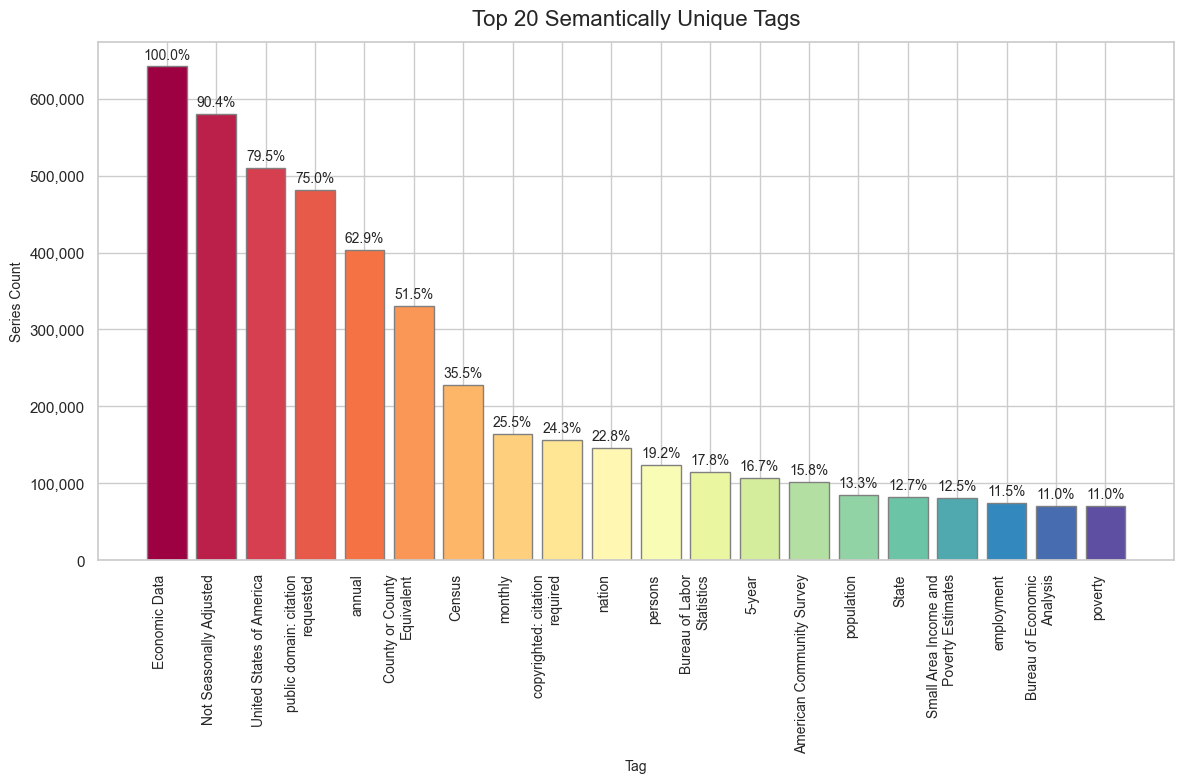

In [65]:
# Prepare data.
tag_counts, total_tags = prepare_top_counts(
    fred,
    "tags_list",
    explode=True,
    # Drop duplicate tags that show up in the plot.
    drop=[
        "St. Louis Fed",
        "Federal Reserve",
        "FRED",
        "nsa",
        "usa",
        "county",
        "census",
        "bls",
        "acs",
        "state",
        "Small Area Income &amp",
        "Poverty Estimates",
        "bea",
    ],
    rename={"saipe": "Small Area Income and Poverty Estimates"},
    top_n=N,
)
# Plot.
plot_top_n_annotated_bar(
    counts=tag_counts,
    total=total,
    top_n=N,
    wrap_width=25,  # wrap long tag names
    figsize=(12, 8),
    dpi=100,
    xlabel="Tag",
    ylabel="Series Count",
    title=f"Top {N} Semantically Unique Tags",
    rotation=90,  # vertical x-labels
    fontsize_title=16,
    fontsize_labels=10,
    fontsize_annotation=10,
    fontsize_note=11,
    formatter=FuncFormatter(lambda y, pos: f"{int(y):,}"),
    show_coverage_note=False,
)
plt.tight_layout()
plt.show()

<a name='distribution-of-tag-categories'></a>
### Distribution of Tag Categories

In [66]:
def categorize_tags(
    column: pd.core.series.Series, model: str, batch_size=50
) -> Dict[str, str]:
    """
    Categorize tags using the fixed categorization prompt.

    :param tags: tags to assign categories
    :param model: model name for classification
    :param batch_size: number of tags per API request
    :return: mapping from tag to category
    """
    SYSTEM_PROMPT = (
        "You are an expert economist. For each input tag, "
        "assign it to one of the following broad categories: "
        "Geography, Frequency, Data Source, Entity, Meta, Other. "
        "Respond in the format “1: Category” for each numbered tag."
    )
    # Extract unique tags.
    unique_tags = list({tag.strip() for tags in column.dropna() for tag in tags})
    results = {}
    # Batch tags for API calls.
    for start in range(0, len(unique_tags), batch_size):
        batch = unique_tags[start : start + batch_size]
        user = "\n".join(f"{i + 1}: {tag}" for i, tag in enumerate(batch))
        response = hopenai.get_completion(
            user, system_prompt=SYSTEM_PROMPT, model=model
        )
        # Parse each line of the response.
        for line in response.splitlines():
            m = re.match(r"(\d+): (.*)", line)
            if m:
                idx = int(m.group(1)) - 1
                results[batch[idx]] = m.group(2).strip()
    return results

OpenAI API call ... 
OpenAI API call done (3.116 s)
OpenAI API call ... 
OpenAI API call done (2.708 s)
OpenAI API call ... 
OpenAI API call done (2.359 s)
OpenAI API call ... 
OpenAI API call done (3.008 s)
OpenAI API call ... 
OpenAI API call done (2.385 s)
OpenAI API call ... 
OpenAI API call done (3.587 s)
OpenAI API call ... 
OpenAI API call done (2.583 s)
OpenAI API call ... 
OpenAI API call done (2.429 s)
OpenAI API call ... 
OpenAI API call done (2.271 s)
OpenAI API call ... 
OpenAI API call done (2.460 s)
OpenAI API call ... 
OpenAI API call done (7.766 s)
OpenAI API call ... 
OpenAI API call done (2.263 s)
OpenAI API call ... 
OpenAI API call done (2.201 s)
OpenAI API call ... 
OpenAI API call done (3.055 s)
OpenAI API call ... 
OpenAI API call done (6.390 s)
OpenAI API call ... 
OpenAI API call done (2.310 s)
OpenAI API call ... 
OpenAI API call done (4.056 s)
OpenAI API call ... 
OpenAI API call done (4.844 s)
OpenAI API call ... 
OpenAI API call done (6.948 s)
OpenAI API c

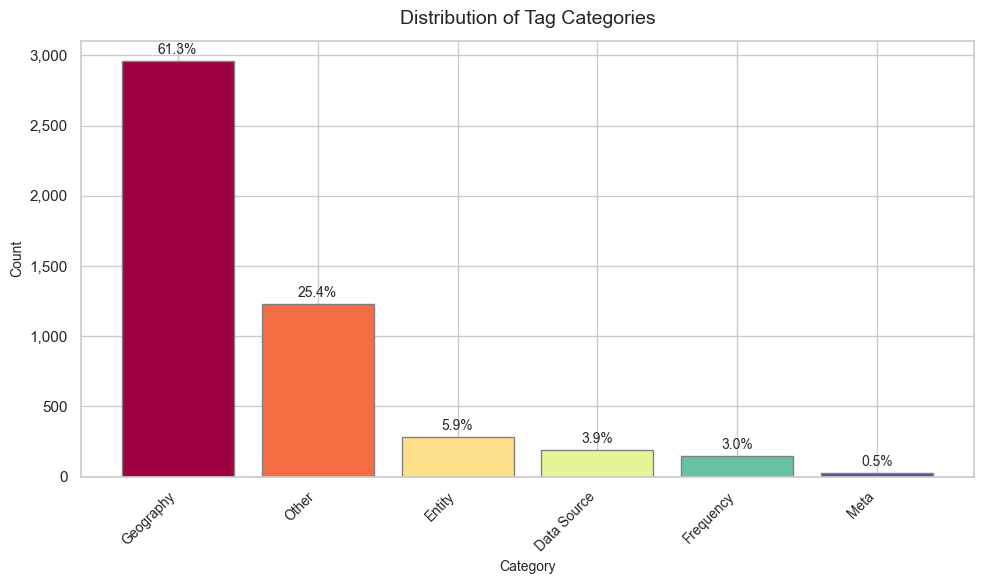

In [69]:
# Prepare data.
model = "gpt-4o-mini"
tag_categories = categorize_tags(fred["tags_list"], model)
category_counts = pd.Series(list(tag_categories.values())).value_counts()
# Plot.
fig, ax = plot_top_n_annotated_bar(
    counts=category_counts,
    total=category_counts.sum(),
    top_n=len(category_counts),
    wrap_width=25,
    figsize=(10, 6),
    dpi=100,
    xlabel="Category",
    ylabel="Count",
    title="Distribution of Tag Categories",
    rotation=45,
    fontsize_title=14,
    fontsize_labels=10,
    fontsize_annotation=10,
    show_coverage_note=False,
    annotation_fmt="{pct:.1f}%",
)
plt.show()

- **Geography dominates (~60%)**
  Most tags refer to places (states, counties, regions, countries, Fed districts, etc.), reflecting that FRED series are often keyed to specific locations.

- **“Other” is the next largest bucket (~27%)**
  This catch-all contains tags that didn’t cleanly fit any of the six categories—mixed jargon, ambiguous terms, industry labels, etc.—so there may be room to refine or split this group further.

- **Entity tags are modest (~6%)**
  These cover named organizations, agencies, instruments or corporate/people names. Their smaller share suggests metadata focuses more on where than who or what.

- **Data source (~3%) and frequency (~3%) are underrepresented**
  Despite being important metadata dimensions, tags like “monthly”, “quarterly”, or “CPI” appear relatively infrequently—perhaps because frequency and source are captured elsewhere in structured columns.

- **Meta (“citation required”, “not seasonally adjusted”, etc.) is tiny (<1%)**
  Very few tags convey processing status or quality notes; tagging conventions here may be inconsistent or sparse.

<a name='count-of-tags-and-categories-per-series'></a>
### Count of Tags and Categories per Series

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Distribution of Categories vs. Tags per Series'}, xlabel='Number per Series', ylabel='Count'>)

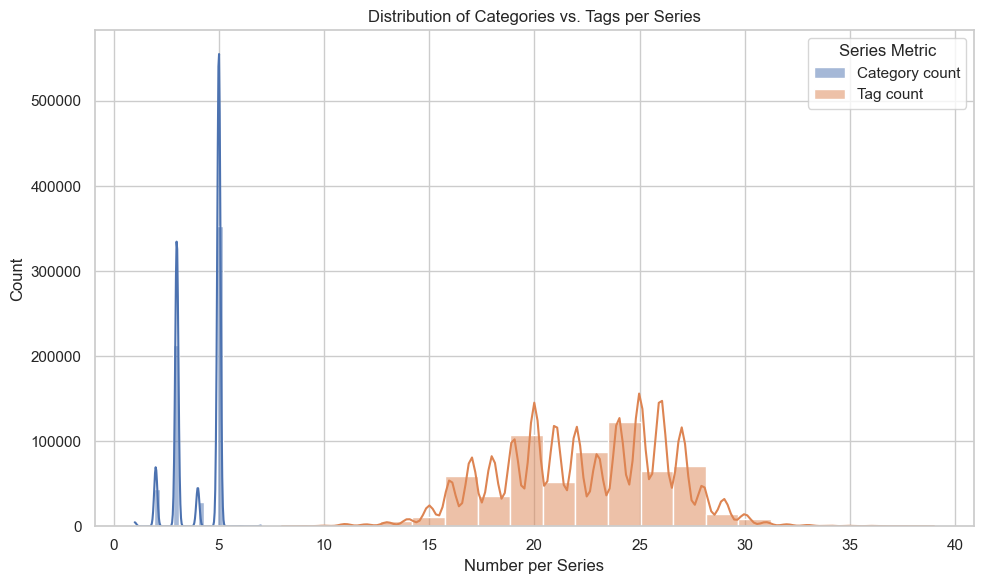

In [70]:
# Plot.
plot_histograms(
    data_series=[fred["n_categories"], fred["n_tags"]],
    labels=["Category count", "Tag count"],
    colors=["C0", "C1"],
    bins=20,
    kde=True,
    figsize=(10, 6),
    xlabel="Number per Series",
    title="Distribution of Categories vs. Tags per Series",
    legend_title="Series Metric",
)

- **Categories are very coarse**
  Most FRED series fall into just 1–6 categories (with a clear spike around 4–5), indicating that the category hierarchy is relatively shallow.

- **Tags are far more granular**
  Tag counts per series cluster around 20–25 and extend past 35, showing that FRED uses tags to capture much finer detail.

<a name='top-tags-for-each-root-category'></a>

### Top Tags for Each Root Category

In [71]:


def get_top_tags_by_root(
    df: pd.DataFrame,
    categories_col: str = "categories",
    tags_col: str = "tags_list",
    redundant: set[str] = None,
    top_n: int = 10,
) -> pd.DataFrame:
    """
    For each root category, find the top-N most common tags excluding any in
    redundant.

    :param df: the source data containing category and tags columns
    :param categories_col: the name of the column with category data
    :param tags_col: the name of the column with tags list
    :param redundant: the set of tags to exclude from the counts
    :param top_n: the maximum number of tags to return per root category
    :return: columns root, tag, count
    """
    if redundant is None:
        redundant = set()
    redundant_lower = {t.lower() for t in redundant}
    # Compute each series’ root category.
    root_series = (
        df[categories_col]
        .fillna("")
        .str.split(";", n=1)
        .str[0]
        .str.strip()
        .replace("", np.nan)
    )
    # For each series, tally up how often each tag appears under its corresponding root category.
    counts: dict[str, Counter] = defaultdict(Counter)
    for tags, root in zip(df[tags_col], root_series):
        if pd.isna(root) or not tags:
            continue
        for tag in set(tags):
            t = tag.strip()
            if not t or t.lower() in redundant_lower:
                continue
            counts[root][t] += 1
    # Extract the top-N tags for each root.
    rows = []
    for root, ctr in counts.items():
        for tag, cnt in ctr.most_common(top_n):
            rows.append({"root": root, "tag": tag, "count": cnt})

    top10 = (
        pd.DataFrame(rows)
        .sort_values(["root", "count"], ascending=[True, False])
        .groupby("root", as_index=False)
        .head(top_n)
    )
    return top10

In [72]:
# Drop duplicate tags that show up in the plot.
REDUNDANT = {
    "Federal Reserve",
    "FRED",
    "nsa",
    "usa",
    "county",
    "census",
    "bls",
    "acs",
    "state",
    "Small Area Income &amp",
    "Poverty Estimates",
    "ppp",
    "pwt",
    "oecd",
    "mei",
    "bea",
    "gdp",
    "nipa",
    "upenn",
    "St. Louis Fed",
    "sa",
    "naics",
    "indexes",
}
top10 = get_top_tags_by_root(
    df=fred,
    categories_col="categories",
    tags_col="tags_list",
    redundant=REDUNDANT,
    top_n=10,
)

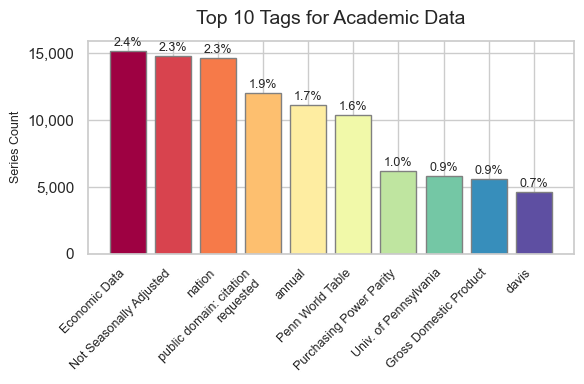

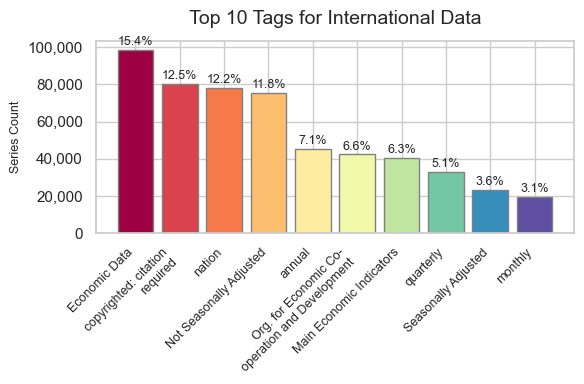

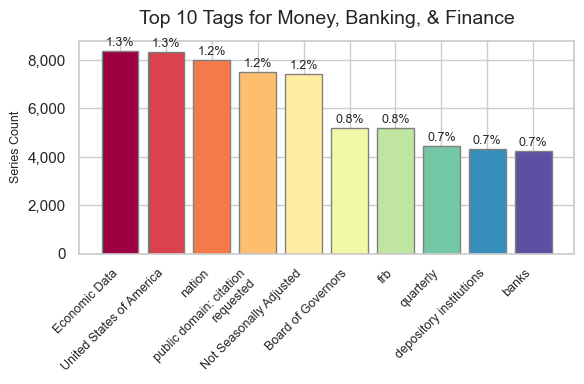

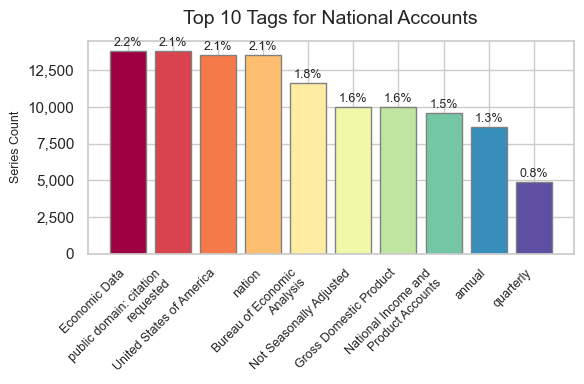

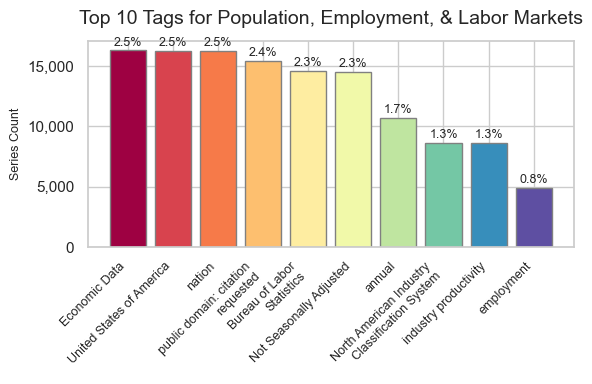

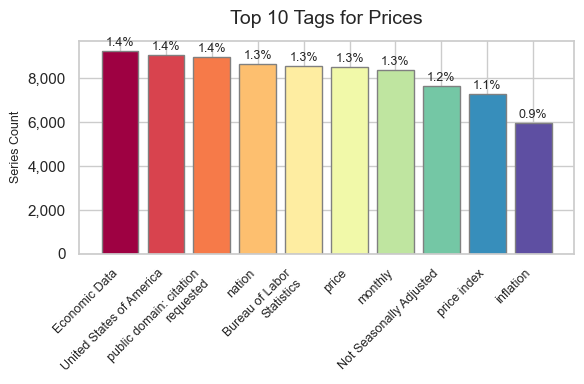

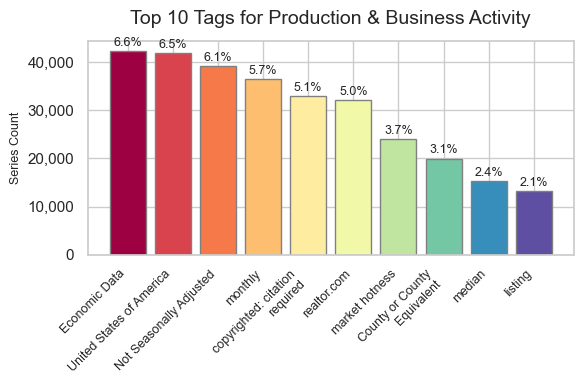

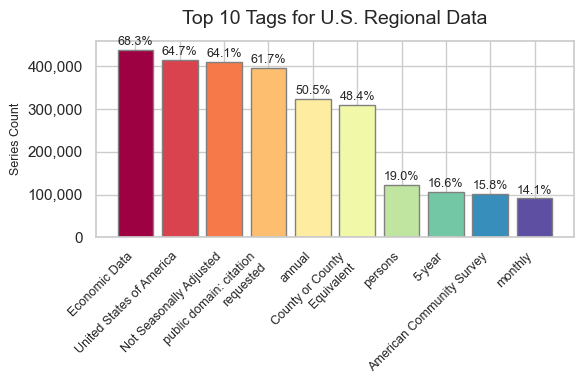

In [73]:

# Compute total tag‐counts per root (for coverage %).
root_totals = top10.groupby("root")["count"].sum()
# For each root, pull out its top‐10 tags.
for root, grp in top10.groupby("root"):
    s = grp.set_index("tag")["count"]
    total_for_root = root_totals[root]
    fig, ax = plot_top_n_annotated_bar(
        counts=s,
        total=total,
        top_n=len(s),
        wrap_width=25,
        cmap=plt.cm.Spectral,
        figsize=(6, 4),
        dpi=100,
        xlabel="",
        ylabel="Series Count",
        title=f"Top 10 Tags for {root}",
        rotation=45,
        fontsize_title=14,
        fontsize_labels=9,
        fontsize_annotation=9,
        annotation_fmt="{pct:.1f}%",
        show_coverage_note=False,
        note_prefix="Top 10 cover ",
    )
    plt.show()

1. **“Economic Data” is everywhere**
   - Ranks #1 in all root categories
   - Covers **68%** of U.S. Regional Data, **15%** of International Data, but still appears in ~6–7% of specialized areas like Production & Business Activity and Money, Banking & Finance

2. **Common metadata tags dominate**
   - **Not Seasonally Adjusted**, **public domain: citation requested**, **United States of America** all sit in the top 4 for most categories
   - Their prevalence ranges from 60 +% in U.S.‐centric feeds down to ~1–2% in niche domains

3. **Concentration vs. dispersion**
   - **U.S. Regional Data** and **International Data** show “head” models: a handful of tags cover the majority, then a steep drop‐off
   - **Prices**, **National Accounts**, etc. display a flatter top 10 (each tag ~1–2%), indicating a long tail of descriptors

4. **Category-specific spikes**
   - **International Data**: “Economic Data” hits ~15%, double its share elsewhere
   - **Population, Employment & Labor Markets**: top tags cluster around ~2.5%, reflecting very diverse labeling


<a name='geographical-analysis'></a>
## Geographical Analysis

<a name='us-vs-non-us'></a>
### US vs Non-US

(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'US vs Non-US Data'}>)

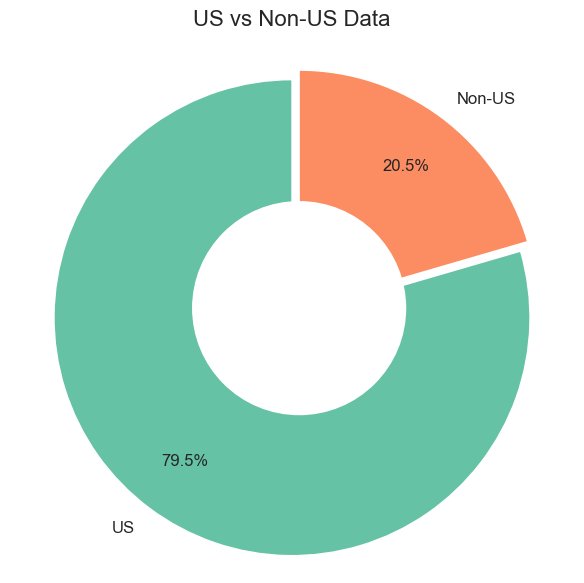

In [74]:

# Prepare data.
labels, sizes = get_binary_counts(
    fred,
    pattern=r"\b(?:usa|united states of america)\b",
    search_cols=["tags", "categories", "title", "description", "notes"],
    labels=["US", "Non-US"],
)
# Plot.
plot_donut(sizes=sizes, labels=labels, title="US vs Non-US Data")

<a name='breakdown-by-continent'></a>
### Breakdown by Continent

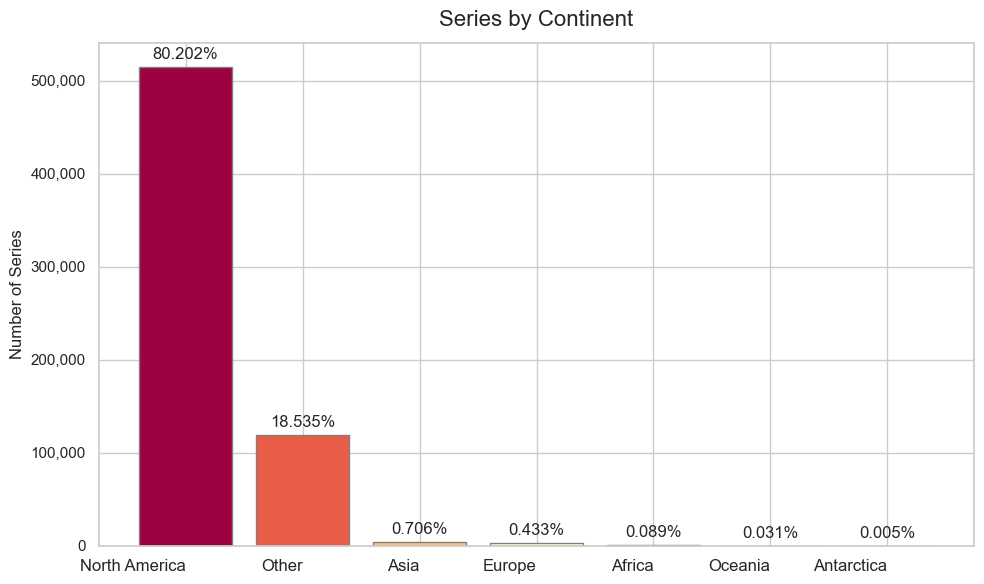

In [75]:
# Prepare data.
cont_counts, total_cont = prepare_top_counts(fred, "continent")
# Plot.
plot_top_n_annotated_bar(
    counts=cont_counts,
    total=total,
    top_n=len(cont_counts),
    wrap_width=None,
    figsize=(10, 6),
    dpi=100,
    xlabel="",
    ylabel="Number of Series",
    title="Series by Continent",
    rotation=0,
    fontsize_title=16,
    fontsize_labels=12,
    fontsize_annotation=12,
    fontsize_note=11,
    formatter=FuncFormatter(lambda y, pos: f"{int(y):,}"),
    show_coverage_note=False,
    annotation_fmt="{pct:.3f}%",
)
plt.tight_layout()
plt.show()

- **Asia Second**
  Besides North America, the most data recorded pertains to Asia, Europe, Africa, Oceania and Anatarctica respectively.


<a name='distribution-of-data-by-state'></a>
### Distribution of Data by State

In [76]:
def plot_choropleth_map(
    patches,
    values,
    *,
    cmap: str = "viridis",
    vmin: float | None = None,
    vmax: float | None = None,
    style: str = "ggplot",
    figsize: tuple = (15, 10),
    dpi: int = 100,
    facecolor: str = "#f7f7f7",
    edgecolor: str = "white",
    linewidth: float = 0.5,
    cbar_orientation: str = "horizontal",
    cbar_fraction: float = 0.04,
    cbar_pad: float = 0.05,
    cbar_label: str = "",
    title: str = "",
    title_kwargs: dict | None = None,
) -> Tuple[matplotlib.figure.Figure, matplotlib.axes.Axes]:
    """
    Plot a choropleth given a list of patch objects and corresponding values.

    :param patches: collection of patch objects for geographical areas
    :param values: numerical values corresponding to patches
    :param cmap: colormap name to use
    :param vmin: minimum value for normalization optional
    :param vmax: maximum value for normalization optional
    :param style: style name for plot optional
    :param figsize: figure dimensions optional
    :param dpi: dots per inch resolution optional
    :param facecolor: background color for plot area optional
    :param edgecolor: color for patch boundaries optional
    :param linewidth: line thickness for patch outlines optional
    :param cbar_orientation: direction of colorbar optional
    :param cbar_fraction: fraction parameter for colorbar size optional
    :param cbar_pad: padding between plot and colorbar optional
    :param cbar_label: label for colorbar optional
    :param title: plot title
    :param title_kwargs: optional keyword arguments for title formatting
    :return: choropleth map
    """
    if style:
        plt.style.use(style)
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    ax.set_facecolor(facecolor)
    # Normalize color scale.
    norm = plt.Normalize(
        vmin=0 if vmin is None else vmin,
        vmax=(max(values) if vmax is None else vmax),
    )
    # Create patch collection.
    pc = PatchCollection(
        patches,
        array=np.array(values),
        cmap=cmap,
        norm=norm,
        edgecolor=edgecolor,
        linewidth=linewidth,
    )
    ax.add_collection(pc)
    ax.autoscale_view()
    # Colorbar.
    cbar = fig.colorbar(
        pc,
        ax=ax,
        orientation=cbar_orientation,
        fraction=cbar_fraction,
        pad=cbar_pad,
    )
    cbar.set_label(cbar_label, fontsize=12)
    cbar.ax.tick_params(labelsize=10)
    # Title.
    if title:
        ax.set_title(
            title,
            **(
                {"fontsize": 20, "fontweight": "bold", "pad": 20}
                if title_kwargs is None
                else title_kwargs
            ),
        )

    ax.set_aspect("equal")
    ax.axis("off")
    plt.tight_layout()
    return fig, ax

In [77]:
def get_patches_and_values(
    geo: Dict, fred: pd.DataFrame
) -> Tuple[List[Polygon], List[int]]:
    """
    Compute and return patches and values for a US choropleth map.

    :param geo: the GeoJSON file
    :param fred: data to compute state counts
    :return: states and corresponding values
    """
    # Prepare data.
    raw_counts = fred["categories_list"].explode().value_counts().to_dict()
    geo_states = {feat["properties"]["name"] for feat in geo["features"]}
    state_series = {st: raw_counts.get(st, 0) for st in geo_states}
    # Build patches and values.
    patches = []
    values = []
    for feat in geo["features"]:
        name = feat["properties"]["name"]
        count = state_series.get(name, 0)
        geom = feat["geometry"]
        rings = (
            geom["coordinates"]
            if geom["type"] == "Polygon"
            else [r for poly in geom["coordinates"] for r in poly]
        )
        for ring in rings:
            patches.append(Polygon(ring, closed=True))
            values.append(count)
    return patches, values

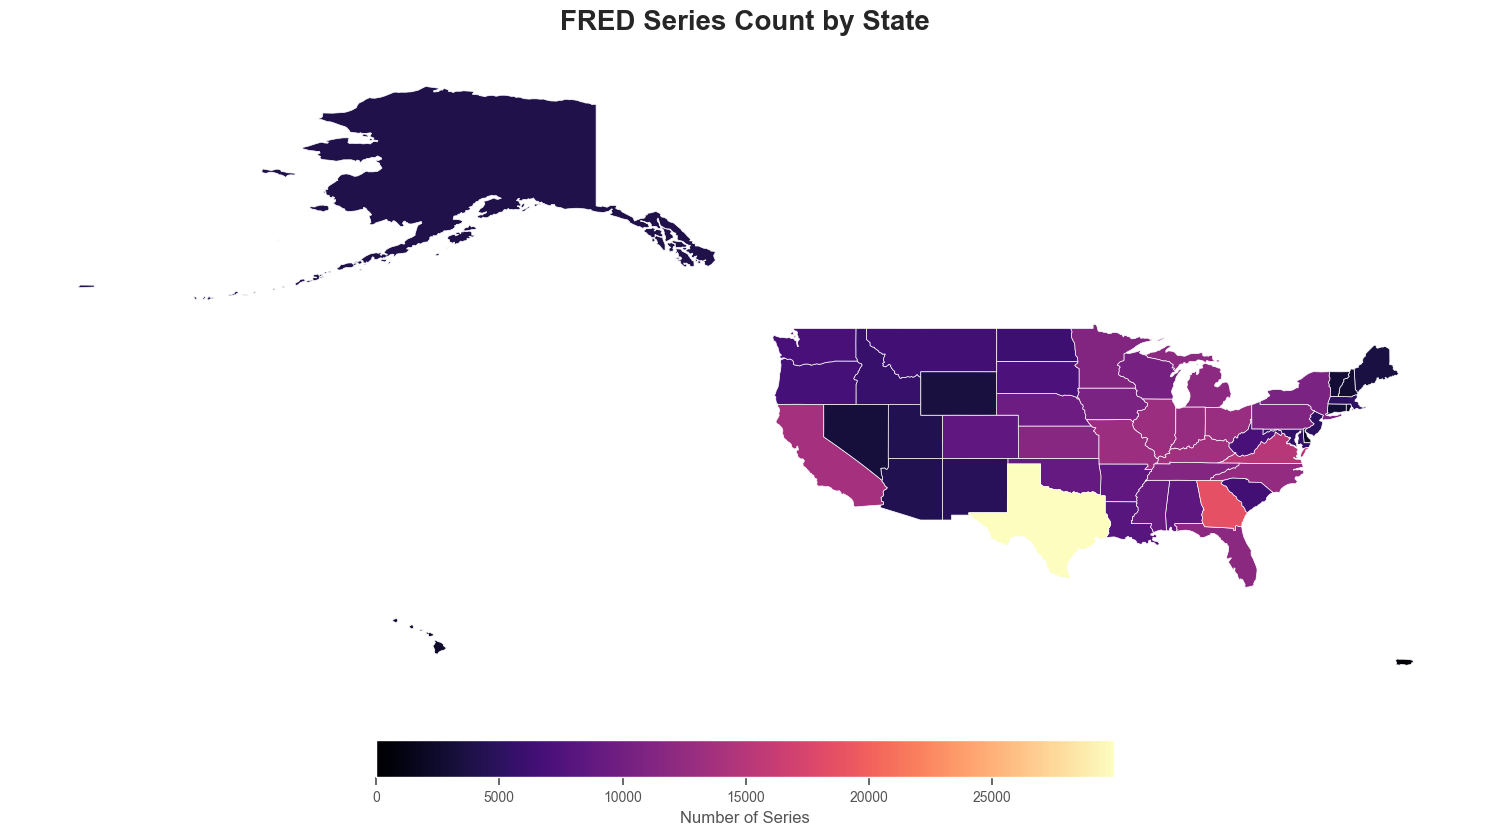

In [78]:
# Compute patches and values using the helper function.
patches, values = get_patches_and_values(geo, fred)
# Plot choropleth.
fig, ax = plot_choropleth_map(
    patches=patches,
    values=values,
    cmap="magma",
    cbar_label="Number of Series",
    title="FRED Series Count by State",
    title_kwargs={"fontsize": 20, "fontweight": "bold", "pad": 20},
)
plt.show()

- **Texas Leads by a Wide Margin**
  Texas stands out with nearly **30,000** series — far more than any other state — reflecting its large and diverse regional datasets.

- **Strong Coverage in Major Economies**
  California (~15K), New York (≈14K), Florida (≈12K) and Georgia (≈20K) all rank in the top tier, consistent with their population size and economic complexity.

- **Moderate Coverage Across the Midwest & Northeast**
  States like Illinois, Ohio, Pennsylvania, Massachusetts and Michigan each host between **8,000–12,000** series, showing solid but less extreme coverage.

- **Sparse Coverage in Rural & Mountain States**
  Many interior and mountain states (e.g., Wyoming, North Dakota, South Dakota, Montana, Vermont) fall below **5,000** series, highlighting regional gaps.

- **Minimal Series in Alaska & Hawai‘i**
  Both non‑contiguous states appear at the low end (< 3,000 series), reflecting fewer localized time‐series data available for those geographies.

Overall, the map shows that FRED’s series are heavily concentrated in the country’s largest and most economically active states, with tapering coverage as populations and economic activity decrease.

<a name='analyses-of-some-derived-features'></a>
## Analyses of some Derived Features

<a name='derived-feature-correlation'></a>
### Derived Feature Correlation

In [79]:
def plot_heatmap(
    matrix,
    *,
    annot: bool = True,
    cmap: str = "coolwarm",
    fmt: str = ".2f",
    cbar: bool = True,
    figsize: tuple = (8, 6),
    title: str = "",
    xlabel: str = "",
    ylabel: str = "",
    **heatmap_kwargs,
) -> Tuple[matplotlib.figure.Figure, matplotlib.axes.Axes]:
    """
    Plot a correlation (or any) matrix as a heatmap.

    :param matrix: the data to be plotted as a heatmap
    :param annot: whether to annotate cells with their values
    :param cmap: colormap name to use
    :param fmt: format for annotations
    :param cbar: whether to show the colorbar
    :param figsize: dimensions for the plot
    :param title: title of the plot
    :param xlabel: label for the x-axis
    :param ylabel: label for the y-axis
    :param heatmap_kwargs: additional keyword arguments passed to the
        heatmap function
    :return: the resulting heatmap figure and axis objects
    """
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        matrix,
        annot=annot,
        fmt=fmt,
        cmap=cmap,
        cbar=cbar,
        ax=ax,
        **heatmap_kwargs,
    )
    ax.set_title(title, pad=12)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    plt.tight_layout()
    return fig, ax

(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': 'Correlation Matrix'}>)

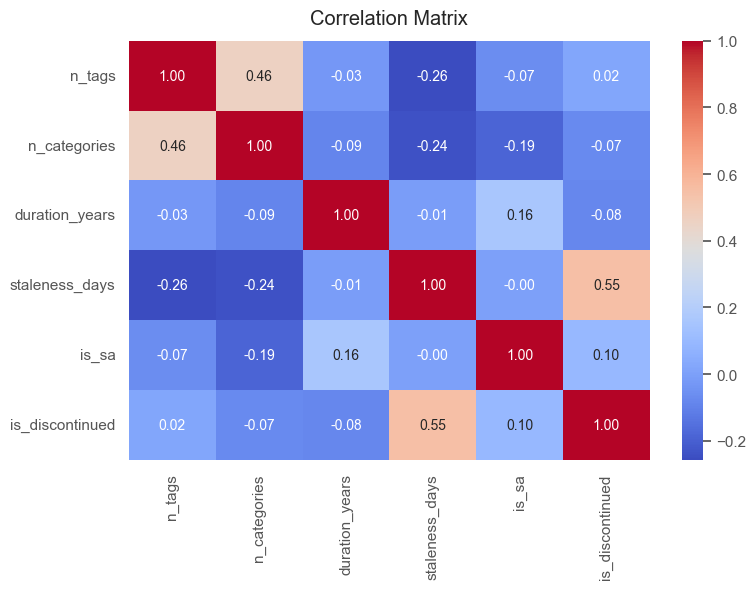

In [80]:
# Prepare data.
num = fred[["n_tags", "n_categories", "duration_years", "staleness_days"]].copy()
num["is_sa"] = (fred["seasonal_adjustment"] != "Not Seasonally Adjusted").astype(
    int
)
num["is_discontinued"] = fred["is_discontinued"].astype(int)
corr = num.corr()
# Plot.
plot_heatmap(
    matrix=corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    figsize=(8, 6),
    title="Correlation Matrix",
)

- **Tags & Categories Go Hand‑in‑Hand**
  The number of tags and number of categories a series has are moderately positively correlated (≈ 0.46), suggesting richer metadata tends to appear in tandem.

- **Discontinuation Tracks Staleness**
  “Days since last update” shows a strong positive correlation (≈ 0.55) with the `is_discontinued` flag—series that haven’t been refreshed in a long time are much more likely to be discontinued.

- **Seasonal Adjustment ↔ Longer Durations**
  There’s a small but notable positive link (≈ 0.16) between being seasonally adjusted and having a longer overall span, reflecting that many long‑running datasets apply seasonal filters.

- **Older Series Lose Metadata**
  Slight negative correlations of staleness with both tag count (≈ –0.26) and category count (≈ –0.24) indicate that older, less‑recently updated series tend to accumulate fewer descriptive tags/categories over time.

- **Duration is Largely Independent**
  Total duration in years has near‐zero correlations with both discontinuation and staleness, implying that simply having a long or short history doesn’t by itself predict whether a series is up‑to‑date or active.

<a name='duration-vs-staleness'></a>
### Duration vs Staleness

In [81]:


def plot_scatterplot(
    df,
    x,
    y,
    figsize=(8, 6),
    dpi=100,
    alpha=0.3,
    s=10,
    title="",
    xlabel="",
    ylabel="",
) -> Tuple[matplotlib.figure.Figure, matplotlib.axes.Axes]:
    """
    Plot a scatterplot.

    :param df: data to plot
    :param x: column name for x-axis
    :param y: column name for y-axis
    :param figsize: size of the figure
    :param dpi: resolution of the figure
    :param alpha: transparency for the points
    :param s: marker size
    :param title: plot title
    :param xlabel: label for the x-axis
    :param ylabel: label for the y-axis
    :return: figure and axes objects for the scatterplot
    """
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    sns.scatterplot(data=df, x=x, y=y, alpha=alpha, s=s, ax=ax)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    plt.tight_layout()
    return fig, ax

(<Figure size 800x600 with 1 Axes>,
 <Axes: title={'center': 'Duration (years) vs. Staleness (days) (Active Series)'}, xlabel='Duration (years)', ylabel='Staleness (days)'>)

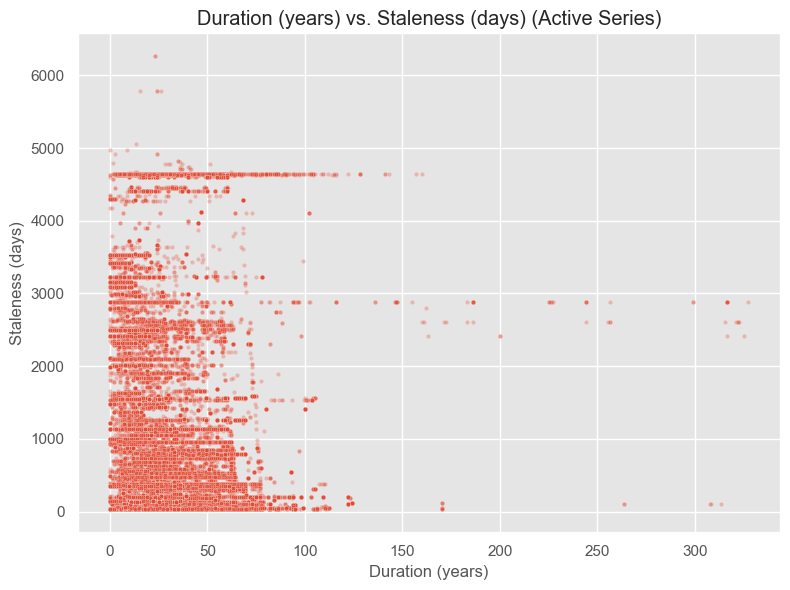

In [83]:
# Prepare data.
active = fred[fred["is_discontinued"] == False]
sample = active.sample(min(len(active), 700000), random_state=1)
# Plot.
plot_scatterplot(
    df=sample,
    x="duration_years",
    y="staleness_days",
    alpha=0.3,
    s=10,
    title="Duration (years) vs. Staleness (days) (Active Series)",
    xlabel="Duration (years)",
    ylabel="Staleness (days)",
)

- **No clear “longer‑lived = fresher” trend** – series that have run for decades (100+ years) can be either very up‑to‑date or months/years stale, and short‐duration series likewise span the full staleness range.
- **High concentration of moderately stale data** – most series cluster with durations under 50 years and staleness around 0–5 years, indicating routine updates even for long‐running indicators.
- **Freshest series (<30 days old)** are predominantly shorter‐duration (≤20 years), suggesting new or recently rebooted series get updated promptly.
- **Outliers**:
  - A handful of very long‑running series (>200 years) show both extremely low staleness (kept current) and very high staleness (archived).
  - Several mid‑life series (~30–60 years) appear in the 6 000–9 000 days staleness band, highlighting neglected datasets that haven’t been refreshed in a decade or more.